# Playercount forecasting — data science project

**Goal.** Given historical playercount numbers for a Steam game, predict the future playercounts.

**Dataset.** *Steam Games Dataset: Player count history, Price history and data about games* — Wannigamage, Barlow, Lakshika & Kasmarik (UNSW Canberra), 2020. DOI [10.17632/ycy3sy3vj2.1](https://data.mendeley.com/datasets/ycy3sy3vj2/1), CC BY 4.0. ~2,000 games at daily resolution.

**Contents.**
1. Setup
2. Data loading
3. Preprocessing — rolling average, causal peaks, normalisation
4. Train/test split by game
5. Training examples — window extraction and targets
6. Baselines
7. Gradient-boosted trees (HistGBR)
8. Decay-rate features and model experiments
9. Error analysis
10. Tag features (in progress)
11. Summary of results

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ["svg"]   # for vector figures
import random
import os
import sklearn
from pathlib import Path
from copy import deepcopy
from datetime import datetime
from datetime import timedelta

print(os.getcwd())

/Users/sujai/Documents/player_forecasting/notebooks


## 2. Creating dataframes

Each game ships as one CSV of daily average player counts. We combine them into a single table (one row per game, one column per day) and truncate at the onset of COVID (2020-03-14): the pandemic shifted playercount behaviour platform-wide.

In [2]:
# we have already processed the raw data from the study in 
# csv_processing.ipynb which is now in one separate csv per game 
input_dir = Path("../data/avg_daily")
df = pd.DataFrame()

rows = []
ids = []
for file in input_dir.glob("*.csv"):
    df = pd.read_csv(file)
    # get playercounts
    rows.append(df["Playercount"].tolist())
    # get the game id
    ids.append(file.name[:-10])

result = pd.DataFrame(rows)

result.insert(0, "game_id", ids)

#remove dates after covid began (any date beyond march 14th 2020)
pre_covid_raw = result.iloc[:,:823]
pre_covid_raw.head()

,game_id,0,1,2,3,4,5,6,7,8,...,812,813,814,815,816,817,818,819,820,821
0,20540,48.597222,54.190972,69.256944,68.645833,51.392361,58.444444,54.795139,54.732639,60.784722,...,58.270833,65.784722,79.269231,83.801394,60.118056,53.088235,57.190972,56.513889,64.746528,84.188153
1,443110,111.875000,114.250000,149.916667,158.458333,126.458333,131.000000,121.875000,141.875000,166.708333,...,151.458333,171.291667,195.041667,202.583333,157.458333,158.291667,157.125000,180.541667,197.666667,231.541667
2,269330,0.260417,0.788194,1.111111,0.888889,0.965278,1.079861,0.819444,10.920139,24.395833,...,0.701389,1.170139,0.642361,0.836237,0.701389,0.923077,0.728223,0.555556,0.472222,0.545139
3,649900,63.416667,65.958333,86.208333,88.208333,67.541667,68.250000,71.458333,80.166667,73.791667,...,13.000000,12.458333,12.208333,14.041667,14.083333,12.083333,11.375000,12.916667,14.250000,14.375000
4,324310,70.666667,85.416667,112.250000,108.458333,69.875000,66.000000,70.750000,77.291667,110.791667,...,24.958333,29.875000,37.041667,42.541667,25.375000,27.166667,24.958333,25.583333,35.916667,52.208333


The same table with calendar dates as column labels (2017-12-14 onward), for readability:

In [3]:
# if you want the columns to have the actual date
dates = pd.date_range("2017-12-14", periods=pre_covid_raw.shape[1] - 1, freq="D")
dated_playercounts = pre_covid_raw.rename(columns=dict(enumerate(dates.date)))
dated_playercounts.head()

,game_id,2017-12-14,2017-12-15,2017-12-16,2017-12-17,2017-12-18,2017-12-19,2017-12-20,2017-12-21,2017-12-22,...,2020-03-05,2020-03-06,2020-03-07,2020-03-08,2020-03-09,2020-03-10,2020-03-11,2020-03-12,2020-03-13,2020-03-14
0,20540,48.597222,54.190972,69.256944,68.645833,51.392361,58.444444,54.795139,54.732639,60.784722,...,58.270833,65.784722,79.269231,83.801394,60.118056,53.088235,57.190972,56.513889,64.746528,84.188153
1,443110,111.875000,114.250000,149.916667,158.458333,126.458333,131.000000,121.875000,141.875000,166.708333,...,151.458333,171.291667,195.041667,202.583333,157.458333,158.291667,157.125000,180.541667,197.666667,231.541667
2,269330,0.260417,0.788194,1.111111,0.888889,0.965278,1.079861,0.819444,10.920139,24.395833,...,0.701389,1.170139,0.642361,0.836237,0.701389,0.923077,0.728223,0.555556,0.472222,0.545139
3,649900,63.416667,65.958333,86.208333,88.208333,67.541667,68.250000,71.458333,80.166667,73.791667,...,13.000000,12.458333,12.208333,14.041667,14.083333,12.083333,11.375000,12.916667,14.250000,14.375000
4,324310,70.666667,85.416667,112.250000,108.458333,69.875000,66.000000,70.750000,77.291667,110.791667,...,24.958333,29.875000,37.041667,42.541667,25.375000,27.166667,24.958333,25.583333,35.916667,52.208333


Convert the dates to `Timestamp` format:

In [4]:
dated_playercounts.columns = [dated_playercounts.columns[0], *pd.to_datetime(dated_playercounts.columns[1:])]
dated_playercounts.head()

,game_id,2017-12-14 00:00:00,2017-12-15 00:00:00,2017-12-16 00:00:00,2017-12-17 00:00:00,2017-12-18 00:00:00,2017-12-19 00:00:00,2017-12-20 00:00:00,2017-12-21 00:00:00,2017-12-22 00:00:00,...,2020-03-05 00:00:00,2020-03-06 00:00:00,2020-03-07 00:00:00,2020-03-08 00:00:00,2020-03-09 00:00:00,2020-03-10 00:00:00,2020-03-11 00:00:00,2020-03-12 00:00:00,2020-03-13 00:00:00,2020-03-14 00:00:00
0,20540,48.597222,54.190972,69.256944,68.645833,51.392361,58.444444,54.795139,54.732639,60.784722,...,58.270833,65.784722,79.269231,83.801394,60.118056,53.088235,57.190972,56.513889,64.746528,84.188153
1,443110,111.875000,114.250000,149.916667,158.458333,126.458333,131.000000,121.875000,141.875000,166.708333,...,151.458333,171.291667,195.041667,202.583333,157.458333,158.291667,157.125000,180.541667,197.666667,231.541667
2,269330,0.260417,0.788194,1.111111,0.888889,0.965278,1.079861,0.819444,10.920139,24.395833,...,0.701389,1.170139,0.642361,0.836237,0.701389,0.923077,0.728223,0.555556,0.472222,0.545139
3,649900,63.416667,65.958333,86.208333,88.208333,67.541667,68.250000,71.458333,80.166667,73.791667,...,13.000000,12.458333,12.208333,14.041667,14.083333,12.083333,11.375000,12.916667,14.250000,14.375000
4,324310,70.666667,85.416667,112.250000,108.458333,69.875000,66.000000,70.750000,77.291667,110.791667,...,24.958333,29.875000,37.041667,42.541667,25.375000,27.166667,24.958333,25.583333,35.916667,52.208333


For each game we also have access to the release date and so we can keep the number of days from release until 2017-12-14 as a potential feature that measures the age of each game.

In [5]:
info_path = "../data/mendeley/applicationInformation.csv"

# only want the date and appid columns to match onto
game_info = pd.read_csv(info_path, encoding_errors="replace", usecols=["appid", "releasedate"])

# make sure both are the same type
game_info["appid"] = game_info["appid"].astype('str')

game_info = game_info.rename(columns={"appid":"game_id"})

In [6]:
dated_playercounts = pd.merge(dated_playercounts, game_info, on="game_id", how="inner")
pre_covid_raw = pd.merge(pre_covid_raw, game_info, on="game_id", how="inner")
dated_playercounts.head()

,game_id,2017-12-14 00:00:00,2017-12-15 00:00:00,2017-12-16 00:00:00,2017-12-17 00:00:00,2017-12-18 00:00:00,2017-12-19 00:00:00,2017-12-20 00:00:00,2017-12-21 00:00:00,2017-12-22 00:00:00,...,2020-03-06 00:00:00,2020-03-07 00:00:00,2020-03-08 00:00:00,2020-03-09 00:00:00,2020-03-10 00:00:00,2020-03-11 00:00:00,2020-03-12 00:00:00,2020-03-13 00:00:00,2020-03-14 00:00:00,releasedate
0,20540,48.597222,54.190972,69.256944,68.645833,51.392361,58.444444,54.795139,54.732639,60.784722,...,65.784722,79.269231,83.801394,60.118056,53.088235,57.190972,56.513889,64.746528,84.188153,8-Apr-09
1,443110,111.875000,114.250000,149.916667,158.458333,126.458333,131.000000,121.875000,141.875000,166.708333,...,171.291667,195.041667,202.583333,157.458333,158.291667,157.125000,180.541667,197.666667,231.541667,17-Nov-17
2,269330,0.260417,0.788194,1.111111,0.888889,0.965278,1.079861,0.819444,10.920139,24.395833,...,1.170139,0.642361,0.836237,0.701389,0.923077,0.728223,0.555556,0.472222,0.545139,12-May-14
3,649900,63.416667,65.958333,86.208333,88.208333,67.541667,68.250000,71.458333,80.166667,73.791667,...,12.458333,12.208333,14.041667,14.083333,12.083333,11.375000,12.916667,14.250000,14.375000,2-Nov-17
4,324310,70.666667,85.416667,112.250000,108.458333,69.875000,66.000000,70.750000,77.291667,110.791667,...,29.875000,37.041667,42.541667,25.375000,27.166667,24.958333,25.583333,35.916667,52.208333,2-Mar-16


In [7]:
dated_playercounts = dated_playercounts.set_index("game_id")
daily_counts = dated_playercounts.T
daily_counts

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
2017-12-14 00:00:00,48.597222,111.875,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.25,268.166667,36.295139,NaN,932.975694,102.25,1114.118056,36.527778,15.368056
2017-12-15 00:00:00,54.190972,114.25,0.788194,65.958333,85.416667,37.736111,NaN,NaN,45.954861,239.708333,...,61.25,208.125,286.166667,36.836806,NaN,955.427083,109.25,1168.815972,36.8125,19.157343
2017-12-16 00:00:00,69.256944,149.916667,1.111111,86.208333,112.25,56.472222,NaN,NaN,46.28125,271.916667,...,94.791667,207.333333,320.291667,48.694444,NaN,1198.753472,146.0,1409.722222,48.041667,29.013889
2017-12-17 00:00:00,68.645833,158.458333,0.888889,88.208333,108.458333,57.982639,NaN,NaN,50.444444,276.375,...,90.041667,210.583333,313.958333,51.524306,NaN,1232.666667,160.0,1444.159722,52.444444,25.833333
2017-12-18 00:00:00,51.392361,126.458333,0.965278,67.541667,69.875,42.052083,108.0,45.0,42.097222,231.5,...,58.75,201.958333,292.333333,34.25,1.0,956.350694,109.583333,1241.513889,42.284722,22.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-11 00:00:00,57.190972,157.125,0.728223,11.375,24.958333,37.628472,3.458333,39.708333,37.171329,161.208333,...,36.708333,11.625,147.166667,25.243056,0.0,776.216783,83.75,2937.132867,19.253472,5.170139
2020-03-12 00:00:00,56.513889,180.541667,0.555556,12.916667,25.583333,36.322917,4.083333,32.375,29.59375,154.125,...,33.416667,12.583333,147.458333,31.225694,0.0,843.191638,78.75,3256.326389,20.614583,3.430556
2020-03-13 00:00:00,64.746528,197.666667,0.472222,14.25,35.916667,40.21875,3.083333,40.166667,32.121528,174.166667,...,46.25,11.208333,153.833333,30.142361,0.0,962.482639,78.375,4207.34375,22.291667,6.798611
2020-03-14 00:00:00,84.188153,231.541667,0.545139,14.375,52.208333,60.569444,3.708333,51.666667,37.66899,209.958333,...,68.583333,15.5,160.666667,46.121528,0.0,1161.202797,107.958333,4808.937063,24.677083,8.413194


## 3. Preprocessing

### 3.1 Rolling average

We want to replace the raw playercounts with rolling averages taken over a 14 day period to remove jitter and weekly periodicity. First move the release date to the top.

In [8]:
daily_counts = pd.concat([daily_counts.iloc[[-1],:], daily_counts.drop('releasedate', axis=0)],axis=0)
daily_counts

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
releasedate,8-Apr-09,17-Nov-17,12-May-14,2-Nov-17,2-Mar-16,19-Aug-14,5-Dec-17,29-Aug-17,14-Jul-17,7-Dec-16,...,17-Apr-14,18-Oct-17,31-Jan-18,15-May-12,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15,6-Jul-10
2017-12-14 00:00:00,48.597222,111.875,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.25,268.166667,36.295139,NaN,932.975694,102.25,1114.118056,36.527778,15.368056
2017-12-15 00:00:00,54.190972,114.25,0.788194,65.958333,85.416667,37.736111,NaN,NaN,45.954861,239.708333,...,61.25,208.125,286.166667,36.836806,NaN,955.427083,109.25,1168.815972,36.8125,19.157343
2017-12-16 00:00:00,69.256944,149.916667,1.111111,86.208333,112.25,56.472222,NaN,NaN,46.28125,271.916667,...,94.791667,207.333333,320.291667,48.694444,NaN,1198.753472,146.0,1409.722222,48.041667,29.013889
2017-12-17 00:00:00,68.645833,158.458333,0.888889,88.208333,108.458333,57.982639,NaN,NaN,50.444444,276.375,...,90.041667,210.583333,313.958333,51.524306,NaN,1232.666667,160.0,1444.159722,52.444444,25.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-10 00:00:00,53.088235,158.291667,0.923077,12.083333,27.166667,31.899306,1.041667,67.095238,35.755556,156.636364,...,30.666667,13.25,146.458333,26.538194,0.125,831.003831,81.458333,3089.980989,20.076389,4.194444
2020-03-11 00:00:00,57.190972,157.125,0.728223,11.375,24.958333,37.628472,3.458333,39.708333,37.171329,161.208333,...,36.708333,11.625,147.166667,25.243056,0.0,776.216783,83.75,2937.132867,19.253472,5.170139
2020-03-12 00:00:00,56.513889,180.541667,0.555556,12.916667,25.583333,36.322917,4.083333,32.375,29.59375,154.125,...,33.416667,12.583333,147.458333,31.225694,0.0,843.191638,78.75,3256.326389,20.614583,3.430556
2020-03-13 00:00:00,64.746528,197.666667,0.472222,14.25,35.916667,40.21875,3.083333,40.166667,32.121528,174.166667,...,46.25,11.208333,153.833333,30.142361,0.0,962.482639,78.375,4207.34375,22.291667,6.798611


Then smooth (`min_periods=1` so the series starts from day one):

In [9]:
rolling_avg = deepcopy(daily_counts)
# index from the first element since first one is release date.
rolling_avg.iloc[1:] = rolling_avg.iloc[1:].rolling(14, min_periods=1).mean()
rolling_avg

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
releasedate,8-Apr-09,17-Nov-17,12-May-14,2-Nov-17,2-Mar-16,19-Aug-14,5-Dec-17,29-Aug-17,14-Jul-17,7-Dec-16,...,17-Apr-14,18-Oct-17,31-Jan-18,15-May-12,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15,6-Jul-10
2017-12-14 00:00:00,48.597222,111.875,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.25,268.166667,36.295139,NaN,932.975694,102.25,1114.118056,36.527778,15.368056
2017-12-15 00:00:00,51.394097,113.0625,0.524306,64.6875,78.041667,37.241319,NaN,NaN,47.838058,235.125,...,60.541667,218.1875,277.166667,36.565972,NaN,944.201389,105.75,1141.467014,36.670139,17.262699
2017-12-16 00:00:00,57.34838,125.347222,0.719907,71.861111,89.444444,43.65162,NaN,NaN,47.319122,247.388889,...,71.958333,214.569444,291.541667,40.608796,NaN,1029.052083,119.166667,1230.885417,40.460648,21.179762
2017-12-17 00:00:00,60.172743,133.625,0.762153,75.947917,94.197917,47.234375,NaN,NaN,48.100452,254.635417,...,76.479167,213.572917,297.145833,43.337674,NaN,1079.955729,129.375,1284.203993,43.456597,22.343155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-10 00:00:00,64.703244,169.229167,0.818324,12.654762,31.473214,45.68362,2.011905,75.66907,37.617834,175.482566,...,38.803571,17.142857,152.017857,32.970238,0.026786,930.269983,86.300595,3485.242705,22.039003,5.331017
2020-03-11 00:00:00,64.77616,167.883929,0.849507,12.71131,31.375,45.682876,2.074405,73.971218,37.33642,175.473638,...,39.508929,16.598214,151.145833,32.480159,0.026786,924.705768,86.699405,3458.854734,22.311325,5.382356
2020-03-12 00:00:00,64.67975,169.401786,0.831947,12.797619,31.116071,45.391953,2.142857,71.253956,36.634076,174.79209,...,39.428571,16.229167,150.880952,32.308036,0.026786,924.897401,87.0,3448.349826,22.531679,5.294643
2020-03-13 00:00:00,65.08476,170.732143,0.81657,12.964286,31.327381,45.259513,2.294643,68.35217,36.239979,175.077804,...,40.056548,15.883929,151.238095,32.204117,0.026786,929.908066,86.91369,3495.760788,22.783912,5.331845


### 3.2 Causal peaks

For each day we record the *causal peak* — the running all-time high (`cummax`) of the series up to that day. Measures how big a game has ever been up till today.

In [10]:
# causal peaks of the raw playercounts
causal_peaks_raw = deepcopy(daily_counts)
causal_peaks_raw.iloc[1:] = causal_peaks_raw.iloc[1:].cummax()
causal_peaks_raw

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
releasedate,8-Apr-09,17-Nov-17,12-May-14,2-Nov-17,2-Mar-16,19-Aug-14,5-Dec-17,29-Aug-17,14-Jul-17,7-Dec-16,...,17-Apr-14,18-Oct-17,31-Jan-18,15-May-12,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15,6-Jul-10
2017-12-14 00:00:00,48.597222,111.875,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.25,268.166667,36.295139,NaN,932.975694,102.25,1114.118056,36.527778,15.368056
2017-12-15 00:00:00,54.190972,114.25,0.788194,65.958333,85.416667,37.736111,NaN,NaN,49.721254,239.708333,...,61.25,228.25,286.166667,36.836806,NaN,955.427083,109.25,1168.815972,36.8125,19.157343
2017-12-16 00:00:00,69.256944,149.916667,1.111111,86.208333,112.25,56.472222,NaN,NaN,49.721254,271.916667,...,94.791667,228.25,320.291667,48.694444,NaN,1198.753472,146.0,1409.722222,48.041667,29.013889
2017-12-17 00:00:00,69.256944,158.458333,1.111111,88.208333,112.25,57.982639,NaN,NaN,50.444444,276.375,...,94.791667,228.25,320.291667,51.524306,NaN,1232.666667,160.0,1444.159722,52.444444,29.013889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-10 00:00:00,95.141343,272.458333,97.475694,88.208333,195.208333,117.663194,108.0,158.25,79.170139,504.428571,...,144.291667,239.125,964.458333,133.09375,1081.875,5992.466899,1134.666667,145471.694444,401.902778,36.808362
2020-03-11 00:00:00,95.141343,272.458333,97.475694,88.208333,195.208333,117.663194,108.0,158.25,79.170139,504.428571,...,144.291667,239.125,964.458333,133.09375,1081.875,5992.466899,1134.666667,145471.694444,401.902778,36.808362
2020-03-12 00:00:00,95.141343,272.458333,97.475694,88.208333,195.208333,117.663194,108.0,158.25,79.170139,504.428571,...,144.291667,239.125,964.458333,133.09375,1081.875,5992.466899,1134.666667,145471.694444,401.902778,36.808362
2020-03-13 00:00:00,95.141343,272.458333,97.475694,88.208333,195.208333,117.663194,108.0,158.25,79.170139,504.428571,...,144.291667,239.125,964.458333,133.09375,1081.875,5992.466899,1134.666667,145471.694444,401.902778,36.808362


In [11]:
# causal peaks of the smoothed playercounts
causal_peaks_av = deepcopy(rolling_avg)
causal_peaks_av.iloc[1:] = causal_peaks_av.iloc[1:].cummax()
causal_peaks_av

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
releasedate,8-Apr-09,17-Nov-17,12-May-14,2-Nov-17,2-Mar-16,19-Aug-14,5-Dec-17,29-Aug-17,14-Jul-17,7-Dec-16,...,17-Apr-14,18-Oct-17,31-Jan-18,15-May-12,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15,6-Jul-10
2017-12-14 00:00:00,48.597222,111.875,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.25,268.166667,36.295139,NaN,932.975694,102.25,1114.118056,36.527778,15.368056
2017-12-15 00:00:00,51.394097,113.0625,0.524306,64.6875,78.041667,37.241319,NaN,NaN,49.721254,235.125,...,60.541667,228.25,277.166667,36.565972,NaN,944.201389,105.75,1141.467014,36.670139,17.262699
2017-12-16 00:00:00,57.34838,125.347222,0.719907,71.861111,89.444444,43.65162,NaN,NaN,49.721254,247.388889,...,71.958333,228.25,291.541667,40.608796,NaN,1029.052083,119.166667,1230.885417,40.460648,21.179762
2017-12-17 00:00:00,60.172743,133.625,0.762153,75.947917,94.197917,47.234375,NaN,NaN,49.721254,254.635417,...,76.479167,228.25,297.145833,43.337674,NaN,1079.955729,129.375,1284.203993,43.456597,22.343155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-10 00:00:00,80.754839,183.753653,18.090791,75.947917,144.181548,98.213653,108.0,136.785714,65.003577,431.952381,...,116.964286,228.25,819.828613,87.080026,108.751941,3009.600092,468.169643,45429.996037,158.486339,26.912672
2020-03-11 00:00:00,80.754839,183.753653,18.090791,75.947917,144.181548,98.213653,108.0,136.785714,65.003577,431.952381,...,116.964286,228.25,819.828613,87.080026,108.751941,3009.600092,468.169643,45429.996037,158.486339,26.912672
2020-03-12 00:00:00,80.754839,183.753653,18.090791,75.947917,144.181548,98.213653,108.0,136.785714,65.003577,431.952381,...,116.964286,228.25,819.828613,87.080026,108.751941,3009.600092,468.169643,45429.996037,158.486339,26.912672
2020-03-13 00:00:00,80.754839,183.753653,18.090791,75.947917,144.181548,98.213653,108.0,136.785714,65.003577,431.952381,...,116.964286,228.25,819.828613,87.080026,108.751941,3009.600092,468.169643,45429.996037,158.486339,26.912672


### 3.3 Dud filter

Remove games which are 'small', meaning their rolling average playercount never reaches more than 100.

In [12]:
# remove games which never had more than 100 players at their rolling all time high average (duds).
dud_cols = []
dud_ids = []
all_time_highs = causal_peaks_av.iloc[-1].tolist()
for i in range(len(all_time_highs)):
    if all_time_highs[i] < 100 or pd.isna(all_time_highs[i]):
        dud_cols.append(i)
        dud_ids.append(causal_peaks_av.columns[i])

print("The games that are filtered out due to low player count are: ", dud_ids)
print("Number of games filtered out:", len(dud_ids))

The games that are filtered out due to low player count are:  ['20540', '269330', '649900', '319510', '523120', '748370', '509240', '2800', '482850', '665180', '263560', '16450', '272230', '546200', '575840', '25830', '98800', '735570', '629690', '383800', '70600', '22350', '497180', '461890', '563120', '7830', '22600', '624910', '32360', '427490', '384480', '467370', '425340', '467000', '542550', '222750', '717790', '226580', '243950', '15210', '545110', '208520', '235320', '435440', '311730', '237870', '214420', '321410', '274900', '245490', '482770', '214170', '22130', '9340', '285010', '420440', '216890', '251950', '45770', '221260', '574810', '515470', '619340', '551670', '346120', '507390', '474050', '421050', '670880', '289930', '480430', '640100', '570420', '629280', '385800', '547960', '213120', '251110', '457730', '251730', '506610', '344230', '620130', '515690', '319910', '568770', '607880', '312280', '244730', '216260', '629030', '201700', '535260', '73010', '265610', '2580

In [13]:
# we drop the above games:
causal_peaks_av = causal_peaks_av.drop(causal_peaks_av.columns[dud_cols], axis=1)
rolling_avg = rolling_avg.drop(rolling_avg.columns[dud_cols], axis=1)

causal_peaks_raw = causal_peaks_raw.drop(causal_peaks_raw.columns[dud_cols], axis=1)
daily_counts = daily_counts.drop(daily_counts.columns[dud_cols], axis=1)

In [14]:
causal_peaks_av

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
releasedate,17-Nov-17,2-Mar-16,5-Dec-17,29-Aug-17,7-Dec-16,12-Feb-13,25-May-17,15-Dec-11,15-Feb-16,22-Oct-14,...,3-Aug-17,23-Oct-15,17-Apr-14,18-Oct-17,31-Jan-18,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15
2017-12-14 00:00:00,111.875,70.666667,NaN,NaN,230.541667,243.243056,21.138889,272.041667,1310.829861,106.625,...,97.5,666.225694,59.833333,228.25,268.166667,NaN,932.975694,102.25,1114.118056,36.527778
2017-12-15 00:00:00,113.0625,78.041667,NaN,NaN,235.125,265.65625,22.386518,273.604167,1416.848958,106.625,...,104.395833,666.225694,60.541667,228.25,277.166667,NaN,944.201389,105.75,1141.467014,36.670139
2017-12-16 00:00:00,125.347222,89.444444,NaN,NaN,247.388889,305.407407,26.689734,296.277778,1530.097222,117.152778,...,109.555556,681.6875,71.958333,228.25,291.541667,NaN,1029.052083,119.166667,1230.885417,40.460648
2017-12-17 00:00:00,133.625,94.197917,NaN,NaN,254.635417,336.667535,28.910158,314.833333,1567.315104,127.0625,...,111.322917,705.002604,76.479167,228.25,297.145833,NaN,1079.955729,129.375,1284.203993,43.456597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-10 00:00:00,183.753653,144.181548,108.0,136.785714,431.952381,624.362049,108.710006,314.833333,2932.255738,326.009524,...,111.322917,1357.319973,116.964286,228.25,819.828613,108.751941,3009.600092,468.169643,45429.996037,158.486339
2020-03-11 00:00:00,183.753653,144.181548,108.0,136.785714,431.952381,624.362049,108.710006,314.833333,2932.255738,326.009524,...,111.322917,1357.319973,116.964286,228.25,819.828613,108.751941,3009.600092,468.169643,45429.996037,158.486339
2020-03-12 00:00:00,183.753653,144.181548,108.0,136.785714,431.952381,624.362049,108.710006,314.833333,2932.255738,326.009524,...,111.322917,1357.319973,116.964286,228.25,819.828613,108.751941,3009.600092,468.169643,45429.996037,158.486339
2020-03-13 00:00:00,183.753653,144.181548,108.0,136.785714,431.952381,624.362049,108.710006,314.833333,2932.255738,326.009524,...,111.322917,1357.319973,116.964286,228.25,819.828613,108.751941,3009.600092,468.169643,45429.996037,158.486339


### 3.4 Causal normalisation

Player counts span four orders of magnitude across games, so we normalise each day's value by the causal peak — expressing every game as a *fraction of its own historical peak*, in $(0, 1]$. First for the raw counts (with a small offset against division by zero at series start):

In [15]:
caus_norm_raw = deepcopy(daily_counts)
caus_norm_raw.iloc[1:] = caus_norm_raw.iloc[1:].div(causal_peaks_raw.iloc[1:] + 0.01)
cnr = caus_norm_raw
cnr.head(3)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
releasedate,17-Nov-17,2-Mar-16,5-Dec-17,29-Aug-17,7-Dec-16,12-Feb-13,25-May-17,15-Dec-11,15-Feb-16,22-Oct-14,...,3-Aug-17,23-Oct-15,17-Apr-14,18-Oct-17,31-Jan-18,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15
2017-12-14 00:00:00,0.999911,0.999859,NaN,NaN,0.999957,0.999959,0.999527,0.999963,0.999992,0.999906,...,0.999897,0.999985,0.999833,0.999956,0.999963,NaN,0.999989,0.999902,0.999991,0.999726
2017-12-15 00:00:00,0.999912,0.999883,NaN,NaN,0.999958,0.999965,0.999577,0.999964,0.999993,0.989747,...,0.99991,0.987936,0.999837,0.911789,0.999965,NaN,0.99999,0.999908,0.999991,0.999728


And the version the models use — the rolling average divided by its causal peak (`caus_norm_av`, elsewhere abbreviated **cna**):

In [16]:
cna = deepcopy(rolling_avg)
cna.iloc[1:] = cna.iloc[1:].div(causal_peaks_av.iloc[1:])
cna.head(3)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
releasedate,17-Nov-17,2-Mar-16,5-Dec-17,29-Aug-17,7-Dec-16,12-Feb-13,25-May-17,15-Dec-11,15-Feb-16,22-Oct-14,...,3-Aug-17,23-Oct-15,17-Apr-14,18-Oct-17,31-Jan-18,10-Jun-16,30-May-17,2-Apr-15,13-Feb-17,2-Sep-15
2017-12-14 00:00:00,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0
2017-12-15 00:00:00,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,0.99492,...,1.0,0.993975,1.0,0.955915,1.0,NaN,1.0,1.0,1.0,1.0


## 4. Train/test split — by game

Data points will be generated by sliding a window along each game's series, so points from the same game share information. Splitting *points* randomly would leak that shared information from train to test. We therefore split **by game**: 90% of games contribute training windows, 10% are held out entirely. The same reasoning motivates grouped cross-validation later. 

### 4.1 Shuffle and split

Shuffle the game order once (seeded, applied identically to every frame), then cut at the 90% boundary:

In [17]:
# assemble dataframes into a dict
dataframes = {"pcr": daily_counts,
              "pca": rolling_avg,
              "cpr": causal_peaks_raw,
              "cpa": causal_peaks_av,
              "cnr": caus_norm_raw,
              "cna": cna}

In [18]:
frames_shuffled = dict()

# randomly shuffle columns and put into new dictionary of dataframes
for key in dataframes:
    frames_shuffled[key] = dataframes[key].sample(frac=1, axis=1, random_state=42)

In [19]:
# divide 90% of the games into train and 10% into test
split_ratio = 0.9
n_games = len(frames_shuffled["cpa"].columns)
n_train_games = int(split_ratio * n_games)

## 5. Training examples

### 5.1 The extractor

We have one time series per game as it stands, all of the same length in time. In a real world scenario a user would not have this exact length of playercount measurements and so we need a model that works when given a smaller input time series. For this reason we will be collecting data points from the time series for each game by sliding a set of windows across the time series as shown below:

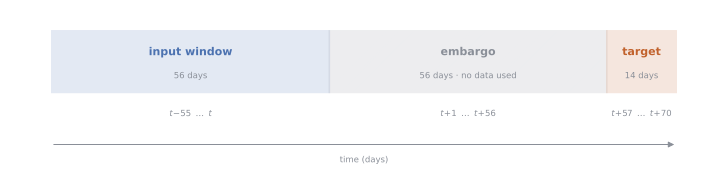

saved to /Users/sujai/Documents/player_forecasting/report/figs/sliding_window.svg


In [20]:
# --- schematic of the sliding-window layout (report figure) -----------------
# Pure diagram - no data dependency, so the palette is repeated locally here
# rather than relying on the constants defined later in section 5.3.
from matplotlib.patches import Rectangle, FancyArrowPatch

RAW_COLOR_ = "#4C72B0"      # input window
LOG_COLOR_ = "#c1622d"      # target window
NEUTRAL_   = "#8a8f98"      # embargo, axes, text

INPUT, EMBARGO, TARGET = 56, 56, 14
x0, x1, x2, x3 = 0, INPUT, INPUT + EMBARGO, INPUT + EMBARGO + TARGET

plt.rcParams["hatch.linewidth"] = 0.5      # must be set before the patches are made

fig, ax = plt.subplots(figsize=(10, 2.3), constrained_layout=True)
ax.set_xlim(-9, x3 + 9)
ax.set_ylim(-0.62, 0.72)
ax.axis("off")

blocks = [
    (x0, x1, RAW_COLOR_, "input window", "56 days",                 r"$t\!-\!55\ \dots\ t$",         None),
    (x1, x2, NEUTRAL_,   "embargo",      "56 days \u00b7 no data used", r"$t\!+\!1\ \dots\ t\!+\!56$",  "////"),
    (x2, x3, LOG_COLOR_, "target",       "14 days",                 r"$t\!+\!57\ \dots\ t\!+\!70$", None),
]

for xa, xb, colour, title, sub, span, hatch in blocks:
    mid = (xa + xb) / 2
    ax.add_patch(Rectangle((xa, 0.0), xb - xa, 0.52, facecolor=colour, alpha=0.16,
                           edgecolor=colour, linewidth=1.6, hatch=hatch, zorder=2))
    ax.text(mid, 0.34, title, ha="center", va="center", fontsize=11,
            color=colour, fontweight="semibold", zorder=3)
    ax.text(mid, 0.14, sub, ha="center", va="center", fontsize=8.5,
            color=NEUTRAL_, zorder=3)
    ax.text(mid, -0.18, span, ha="center", va="center", fontsize=8.5, color=NEUTRAL_)

ax.add_patch(FancyArrowPatch((x0, -0.44), (x3, -0.44), arrowstyle="-|>",
                             mutation_scale=12, color=NEUTRAL_, linewidth=1.0))
ax.text(x3 / 2, -0.57, "time (days)", ha="center", va="center",
        fontsize=8.5, color=NEUTRAL_)

plt.show()

fig_dir = Path("../report/figs")
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "sliding_window.svg", transparent=True, bbox_inches="tight")
print("saved to", (fig_dir / "sliding_window.svg").resolve())

A user would simply need 56 days of playercount data to begin predicting. We choose an embargo of 56 days because that is approximately enough time for game publishers or developers to implement preventative measures against playerbase collapse.

### 5.2 Extractor function and generating data points

In [21]:
def extractor(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, start_date):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    start_date (datetime): datetime of the first day in the time series

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    window_start = 0 
    n_days = len(time_series)
    
    
    while window_start + past_window + embargo + future_window - 1 < n_days:

        # if nan in future window, then shift
        if any(pd.isna(ele) for ele in time_series[window_start + past_window + embargo: window_start + past_window + embargo + future_window]):
            window_start += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[window_start: window_start + past_window]):
            window_start += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            peak_at_window_end = causal_peaks[window_start + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[window_start + past_window + embargo: window_start + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            target = avg / peak_at_window_end

            # take note of the index of the current date (i.e. the day after the end of the input window)
            idx_today = window_start + past_window
            current_date = start_date + timedelta(days = idx_today)

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[window_start: window_start + past_window],
                           target,
                           game_id,
                           current_date))
            
            # shift along
            window_start += future_window

    return points

Generate points for every game (past 56, embargo 56, future 14):

In [22]:
data = []
START_DATE = dataframes["cna"].index[1]
INPUT_WINDOW = 56
EMBARGO = 56
TARGET_WINDOW = 14

# generate data points
for column in frames_shuffled["cna"]:
    game_id = column
    time_series = frames_shuffled["cna"][column].tolist()[1:]
    causal_peaks = frames_shuffled["cpa"][column].tolist()[1:]
    roll_average = frames_shuffled["pca"][column].tolist()[1:]
    data.append(extractor(time_series, INPUT_WINDOW, EMBARGO, TARGET_WINDOW, causal_peaks, roll_average, game_id, START_DATE))

Create a dictionary of `game_id` to release date. May come useful later. Note that some release dates are missing in which case they are converted to `NaT`.

In [23]:
id_date = dataframes["cna"].iloc[:1].to_dict()
release_dates_0 = {game: id_date[game]['releasedate'] for game in id_date}
release_dates = dict()


release_dates = {
    game: pd.to_datetime(date, format="%d-%b-%y", errors="coerce")
    for game, date in release_dates_0.items()
}

### 5.3 Train/test arrays

Split by game at the boundary, flatten the per-game lists, and unpack each tuple into the design matrix, target vector and group labels (game ids, used by `GroupKFold`):

In [24]:
data_train = data[:n_train_games]
data_test = data[n_train_games:]

# flatten
train_points = [point for game in data_train for point in game]
test_points = [point for game in data_test for point in game]

print("There are " + str(len(test_points)) + " test data points.")
print("There are " + str(len(train_points)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


Convert the list of training and test data points into dataframes.

In [25]:
train_frame = pd.DataFrame(train_points, columns=["input window", "target", "game id", "date of sample"])
test_frame = pd.DataFrame(test_points, columns=["input window", "target", "game id", "date of sample"])

### 5.4 Constructing features and target

There are two types of feature we are going to use:

1. Global features -- these are some function of all the playercounts in a games history, i.e. including points outside the input window (but strictly earlier points than the current time.)
2. Local features -- these are functions of the playercounts within the 56 day input window.

The local features can be computed from each data point in `train_points` and `test_points` since these contain the input window playercounts. We want to design the code in a way that if new local features are thought of later, they can be quickly added to the code that generates the design matrix (matrix of input training examples).

One way to do this is to have a list of functions for creating local features, each of which takes as an input one tuple from `train_points` or `test_points` and outputs a feature. We can then write another function whose job it is to iterate through the list of functions, apply each one, and stack their results into a list which is then the feature vector for that one data point. For the global features there may be a better way to do things because pandas may have more natural ways to compute cumulative statistics from dataframes which prevents us repeating redundant calculations.

(what I mean by the last sentence is for example if we are computing the running average of a series we don't need to re-sum the first N terms to get the average of the first N + 1 terms if we are moving through the series from top to bottom)

*UPDATE:* I will try to work entirely with dataframes to handle the data. Each row is an example and we will simply add new features onto the end of the dataframe as needed.

Let's add the release date to each data point

In [26]:
train_frame.head(2)

,input window,target,game id,date of sample
0,"[1.0, 0.9790185763304239, 0.9727999199060717, ...",0.999036,466170,2018-02-08
1,"[0.9779998491737714, 0.9795942514403254, 0.981...",1.015642,466170,2018-02-22


In [27]:
release_frame = pd.DataFrame.from_dict(release_dates, orient="index", columns=["release date"])
release_frame = release_frame.reset_index(names="game id")
release_frame.head()


,game id,release date
0,443110,2017-11-17
1,324310,2016-03-02
2,746910,2017-12-05
3,407530,2017-08-29
4,480650,2016-12-07


In [28]:
train_frame = train_frame.merge(release_frame, on="game id", how="left")
test_frame = test_frame.merge(release_frame, on="game id", how="left")

In [29]:
train_frame.head()

,input window,target,game id,date of sample,release date
0,"[1.0, 0.9790185763304239, 0.9727999199060717, ...",0.999036,466170,2018-02-08,2016-05-27
1,"[0.9779998491737714, 0.9795942514403254, 0.981...",1.015642,466170,2018-02-22,2016-05-27
2,"[0.9939424338133982, 0.9984271972708103, 1.0, ...",1.017969,466170,2018-03-08,2016-05-27
3,"[1.0, 0.9988830379228409, 1.0, 1.0, 1.0, 1.0, ...",1.017693,466170,2018-03-22,2016-05-27
4,"[0.9985352780706288, 0.9988229052678853, 0.993...",1.005361,466170,2018-04-05,2016-05-27


Now we write a bunch of functions that compute local features (based on the input window CNA counts) and then append them to the dataframe

In [34]:
# write some input local feature functions
# the functions should all take dataframe rows as inputs
# function to return input window playercounts

# function to count number of up days and number of down days (or their difference rather)
def up_down(row):
    # find the input window
    counts = row["input window"]
    ups = 0
    downs = 0
    for i in range(len(counts) - 1):
        if counts[i] < counts[i + 1]:
            ups += 1
        elif counts[i] > counts[i + 1]:
            downs += 1

    return ups - downs

# function to compute spread of points (max - min)
def spread(row):
    counts = row["input window"]
    return max(counts) - min(counts)

# function to compute age of game at time of datapoint in days
def age(row):
    return (row["date of sample"] - row["release date"]).days

# define a dict to hold all the input functions
local_functions = {
    "up-down": up_down,
    "spread": spread,
    "age (d)": age}

Now there should be some code that runs over the local functions, applying each one to the dataframe and adding the output as a new column to the `train_frame` and `test_frame` dataframes.

In [32]:
for function_name, function in local_functions.items():
    train_frame[function_name] = train_frame.apply(function, axis=1)

In [33]:
train_frame.head()

,input window,target,game id,date of sample,release date,up-down,spread,age
0,"[1.0, 0.9790185763304239, 0.9727999199060717, ...",0.999036,466170,2018-02-08,2016-05-27,4,0.038144,622.0
1,"[0.9779998491737714, 0.9795942514403254, 0.981...",1.015642,466170,2018-02-22,2016-05-27,3,0.022000,636.0
2,"[0.9939424338133982, 0.9984271972708103, 1.0, ...",1.017969,466170,2018-03-08,2016-05-27,-7,0.017353,650.0
3,"[1.0, 0.9988830379228409, 1.0, 1.0, 1.0, 1.0, ...",1.017693,466170,2018-03-22,2016-05-27,-19,0.035594,664.0
4,"[0.9985352780706288, 0.9988229052678853, 0.993...",1.005361,466170,2018-04-05,2016-05-27,-24,0.050778,678.0


In [35]:
x_train = []

In [36]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in train_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in test_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

IndexError: tuple index out of range

In [ ]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((66424, 58), (66424,), (7410, 58), (7410,))

### 5.4 Log target

The raw target distribution is heavily right-skewed (most windows sit far below peak). We model $\log(y + 0.01)$ instead — the offset guards against $\log 0$ for dead games:

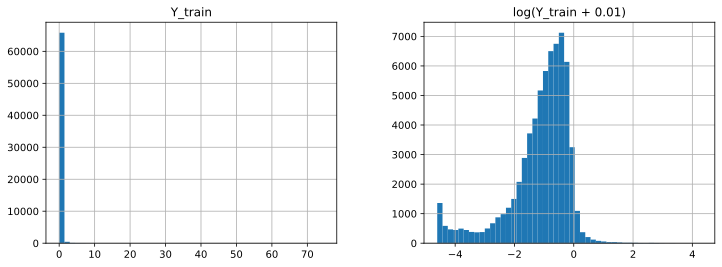

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pd.DataFrame(Y_train).hist(ax=ax1,bins=50)
pd.DataFrame(np.log(Y_train + 0.01)).hist(ax=ax2,bins=50)

ax1.set_title("Y_train")
ax2.set_title("log(Y_train + 0.01)")

plt.show()


In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

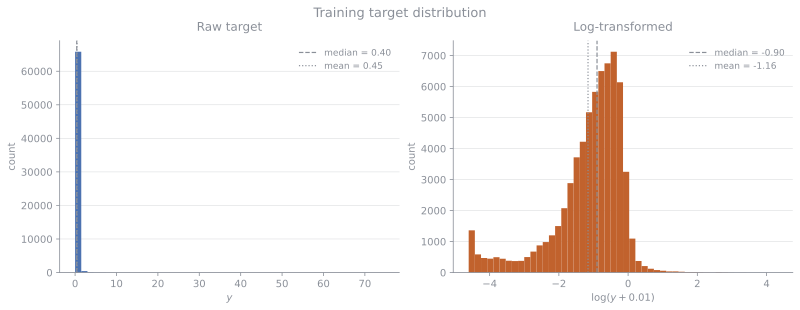

In [ ]:
# --- report figure: target distribution before and after the log transform ---
# Colours chosen to clear 3:1 contrast on BOTH the light (#fff) and dark
# (#222, see report/theme-dark.scss) backgrounds, and the figure is exported
# with transparent=True, so the page background shows through and the same
# SVG reads correctly in either Quarto theme.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

RAW_COLOR = "#4C72B0"   # 4.84 on white / 3.29 on #222
LOG_COLOR = "#c1622d"   # 4.16 on white / 3.83 on #222
NEUTRAL   = "#8a8f98"   # 3.25 on white / 4.90 on #222 - text, spines, guides

for ax, data, color, title, xlabel in [
    (ax1, Y_train,     RAW_COLOR, "Raw target",      "$y$"),
    (ax2, Y_train_log, LOG_COLOR, "Log-transformed", r"$\log(y + 0.01)$"),
]:
    ax.hist(data, bins=50, color=color, edgecolor="none")
    ax.axvline(np.median(data), color=NEUTRAL, linestyle="--", linewidth=1.2,
               label=f"median = {np.median(data):.2f}")
    ax.axvline(np.mean(data), color=NEUTRAL, linestyle=":", linewidth=1.2,
               label=f"mean = {np.mean(data):.2f}")
    ax.set_title(title, fontsize=12, pad=10, color=NEUTRAL)
    ax.set_xlabel(xlabel, color=NEUTRAL)
    ax.set_ylabel("count", color=NEUTRAL)
    ax.tick_params(colors=NEUTRAL)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6, color=NEUTRAL)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(NEUTRAL)
    leg = ax.legend(frameon=False, fontsize=9)
    for text in leg.get_texts():
        text.set_color(NEUTRAL)

fig.suptitle("Training target distribution", fontsize=13, y=1.04, color=NEUTRAL)
plt.show()

In [ ]:
# --- export the figure for the Quarto report ---
fig_dir = Path("../report/figs")
fig_dir.mkdir(parents=True, exist_ok=True)

# transparent=True drops the white canvas so the page background shows through
# and the one file works in both Quarto themes.
fig.savefig(fig_dir / "log_target.svg", bbox_inches="tight", transparent=True)
fig.savefig(fig_dir / "log_target.png", dpi=300, bbox_inches="tight",
            transparent=True)

print("saved to", fig_dir.resolve())

saved to /Users/sujai/Documents/player_forecasting/report/figs


All model scores collect in one dictionary for the final comparison:

In [ ]:
model_scores = dict()

## 6. Baselines

### 6.1 Linear extrapolation

Extend the window's recent slope forward to the target period.

In [ ]:
def linear_extrapolation(x_train):
    # straight line through the FIRST (day 0) and LAST (day 55) points of
    # the window (run = 55 days), extrapolated 56 + 7 days past the window end
    pred = np.maximum(x_train[:, 55] + ((x_train[:,55] - x_train[:,0]) * (56 + 7) / 55.0) , 0.0)
    pred = np.log(pred + 0.01)
    return pred

In [ ]:
Y_pred = linear_extrapolation(X_train)

In [ ]:
from sklearn.metrics import root_mean_squared_error
score = root_mean_squared_error(Y_train_log, Y_pred)

print("The RMSE of this crude baseline model is: " + str(score))
model_scores["linear_extrapolation"] = score

The RMSE of this crude baseline model is: 1.1772722710161225


In [ ]:
# --- Post-peak log-linear extrapolation (new baseline) -----------------------
# Like the log(CNA) least-squares fit, but to stop the flat pre-peak plateau from
# polluting the decay estimate we fit ONLY the decline. For each window we locate
# the peak as the LAST day CNA >= threshold, fit log(CNA + 0.01) from there to the
# window end, and extrapolate to day 55 + 56 + 7 = 118. Returns log-space
# predictions (comparable to Y_train_log), like ls_extrapolation(log_space=True).
# Loops per row because the fit window varies from one example to the next.
def post_peak_log_extrapolation(X, threshold=0.90):
    WINDOW, HORIZON = 56, 56 + 7
    days = np.arange(WINDOW)
    preds = np.empty(len(X))
    for k in range(len(X)):
        win = X[k, :WINDOW]
        above = np.where(win >= threshold)[0]
        p = int(above[-1]) if len(above) else 0     # end of the peak; else whole window
        p = min(p, WINDOW - 2)                       # keep at least 2 points to fit
        slope, icpt = np.polyfit(days[p:], np.log(win[p:] + 0.01), 1)
        preds[k] = slope * (WINDOW - 1 + HORIZON) + icpt
    return preds


In [ ]:
# --- 6.1b Least-squares linear extrapolation -------------------------------
# The crude version above sets the slope from just the first and last two points (indices 0
# and 55), so a single noisy day swings the whole forecast. Here the slope comes
# from a least-squares fit over all 56 window days, which averages that noise
# out. Fitted two ways:
#   "raw" - fit cna directly, so the forecast is a straight line (can go
#           negative, hence the clamp at 0 before the log, as above).
#   "log" - fit log(cna), so the forecast is exponential decay: it can never
#           go negative and matches how playerbases actually decay.
HORIZON = 56 + 7          # days past the end of the window, as in the crude model
WINDOW = 56

def ls_extrapolation(X, log_space=False):
    days = np.arange(WINDOW)
    series = X[:, :WINDOW]

    # polyfit takes the y-values column-wise, so each COLUMN must be one
    # window: pass series.T to fit all rows in a single vectorised call.
    y = np.log(series + 0.01) if log_space else series
    slope, intercept = np.polyfit(days, y.T, deg=1)

    # value of the fitted line at t = 55 + HORIZON (day 55 is the window end)
    pred = slope * (WINDOW - 1 + HORIZON) + intercept

    if log_space:
        return pred                       # already in log space - the target's units
    return np.log(np.maximum(pred, 0.0) + 0.01)

for name, log_space in [("least_squares_raw", False), ("least_squares_log", True)]:
    Y_pred_ls = ls_extrapolation(X_train, log_space=log_space)
    score_ls = root_mean_squared_error(Y_train_log, Y_pred_ls)
    model_scores[name] = score_ls
    print(f"{name:<20} RMSE: {score_ls:.4f}")

print(f"{'(crude two-point)':<20} RMSE: {model_scores['linear_extrapolation']:.4f}")

least_squares_raw    RMSE: 1.3314
least_squares_log    RMSE: 1.0390
(crude two-point)    RMSE: 1.1773


showing candidate 1 of 210 (game 296970)


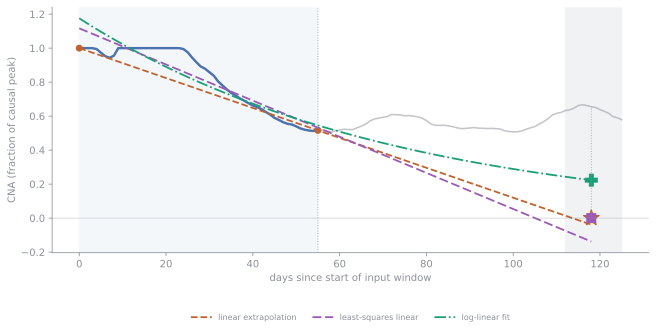

In [ ]:
# --- Illustration: three extrapolation baselines on one window --------------
# linear_extrapolation continues the two-point (day 0 -> 55) slope 56 + 7 days
# past the window end (to day 118); the log-linear least-squares fit to log(CNA)
# does the same as smooth exponential decay. The actual (unseen) CNA is overlaid
# to show where each lands. Palette matches the log-target figure (theme-aware).

# --- choose which training window to plot -----------------------------------
EXAMPLE_RANK = 0        # 0 = clearest case; set 1, 2, 3 ... to cycle through others
EXAMPLE_ROW  = None     # or set a specific training-row index to plot that exact window

pred_all = np.exp(linear_extrapolation(X_train)) - 0.01   # the function, back in CNA units
x0, x55 = X_train[:, 0], X_train[:, 55]

def build_example(idx):
    """(idx, ws, seg, target) for a training row; target is nan if it has no full future."""
    ws = int(X_train[idx, 56]) - 55               # col 56 = window-end index in the full series
    series = frames_shuffled["cna"][groups_train[idx]].to_numpy(dtype=float)
    seg = series[ws: ws + 126]                    # window(56) + embargo(56) + target(14)
    target = float(np.nanmean(seg[112:126])) if len(seg) >= 126 else np.nan
    return idx, ws, seg, target

if EXAMPLE_ROW is not None:
    i, ws, seg, target = build_example(EXAMPLE_ROW)
    print(f"showing training row {i} (game {groups_train[i]})")
else:
    # illustrative candidates: near peak early, ~halved by the end, forecast a crash
    mask = (x0 >= 0.95) & (x55 > 0.45) & (x55 < 0.6) & (x55 < x0) & (pred_all < 0.15)
    if mask.sum() == 0:
        mask = (x55 < x0) & (pred_all < 0.3)      # broaden if the strict set is empty
    rows = []
    for k in np.where(mask)[0]:
        _, ws_k, seg_k, tgt_k = build_example(k)
        if len(seg_k) < 126 or np.isnan(seg_k).any():
            continue
        flat = (np.std(seg_k[56:]) < 0.08) and (abs(tgt_k - x55[k]) < 0.12)
        rows.append((k, ws_k, seg_k, tgt_k, tgt_k - pred_all[k], flat))
    pool = [r for r in rows if r[5]] or rows       # prefer clean 'declined then plateaued'
    pool.sort(key=lambda r: r[4], reverse=True)     # biggest error first
    rank = EXAMPLE_RANK % len(pool)                 # wrap so any integer is valid
    i, ws, seg, target = pool[rank][:4]
    print(f"showing candidate {rank + 1} of {len(pool)} (game {groups_train[i]})")

t = np.arange(len(seg))

# crude linear extrapolation: straight line through window days 0 and 55
a, b, pred = x0[i], x55[i], pred_all[i]
slope = (b - a) / 55.0
line_t = np.array([0, 118]); line_y = b + slope * (line_t - 55)

# least-squares straight line fit to CNA over the whole window (ls_extrapolation, raw)
LS_COLOR = "#9b59b6"
slope_raw, icpt_raw = np.polyfit(np.arange(56), seg[:56], 1)
raw_t = np.array([0, 118]); raw_line = slope_raw * raw_t + icpt_raw
pred_raw = float(np.exp(ls_extrapolation(X_train[i:i + 1], log_space=False)[0]) - 0.01)

# log-linear least-squares fit to log(CNA) over the window (exponential decay in CNA)
FIT_COLOR = "#1b9e77"
slope_log, icpt_log = np.polyfit(np.arange(56), np.log(seg[:56] + 0.01), 1)
fit_t = np.arange(0, 119)
fit_curve = np.exp(slope_log * fit_t + icpt_log) - 0.01
pred_log = float(np.exp(slope_log * 118 + icpt_log) - 0.01)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.axvspan(0, 55, color=RAW_COLOR, alpha=0.06)                    # input window region
ax.axvspan(112, 125, color=NEUTRAL, alpha=0.12)                  # target window region
ax.plot(t, seg, color=NEUTRAL, alpha=0.5, lw=1.6)                 # actual CNA (unseen future)
ax.plot(np.arange(56), seg[:56], color=RAW_COLOR, lw=2.4)        # input window
ax.plot(line_t, line_y, color=LOG_COLOR, ls="--", lw=1.8, label="linear extrapolation")
ax.plot([0, 55], [a, b], "o", color=LOG_COLOR, ms=6)            # window endpoints define the crude line
ax.plot(118, pred, "*", color=LOG_COLOR, ms=17)                  # crude landing point
ax.plot(raw_t, raw_line, color=LS_COLOR, ls=(0, (5, 2)), lw=1.8, label="least-squares linear")
ax.plot(118, pred_raw, "s", color=LS_COLOR, ms=9)               # its landing point
ax.plot(fit_t, fit_curve, color=FIT_COLOR, ls="-.", lw=1.8, label="log-linear fit")
ax.plot(118, pred_log, "P", color=FIT_COLOR, ms=12)             # its landing point
ax.axhline(0, color=NEUTRAL, lw=0.6, alpha=0.5)
ax.axvline(55, color=NEUTRAL, ls=":", lw=1, alpha=0.7)           # window end
if len(seg) > 118:                                               # prediction date up to the CNA curve
    ax.plot([118, 118], [0, seg[118]], color=NEUTRAL, ls=":", lw=1, alpha=0.7)
ax.set_xlabel("days since start of input window", color=NEUTRAL)
ax.set_ylabel("CNA (fraction of causal peak)", color=NEUTRAL)
ax.tick_params(colors=NEUTRAL)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(NEUTRAL)
# small legend under the x-axis describing the three fit lines
leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3,
                frameon=False, fontsize=8, handlelength=2.6)
for txt in leg.get_texts():
    txt.set_color(NEUTRAL)
plt.show()

In [ ]:
# --- export this figure to the report (run after the figure cell above) -----
fig_dir = Path("../report/figs")
fig_dir.mkdir(parents=True, exist_ok=True)
# transparent so the page background shows through in both light and dark themes
fig.savefig(fig_dir / "extrapolation_baselines.svg", transparent=True, bbox_inches="tight")
print("saved to", (fig_dir / "extrapolation_baselines.svg").resolve())

saved to /Users/sujai/Documents/player_forecasting/report/figs/extrapolation_baselines.svg


In [ ]:
# --- Export 50 random examples for the interactive viewer in the report -----
# Same three-baseline figure, drawn for 50 randomly chosen training windows
# (seeded, so the set is reproducible) and saved as transparent SVGs. The
# report embeds these behind a slider so the reader can flip through them.
# Run order: the figure cell above must run first (defines build_example,
# pred_all and the palette).
EXPORT_DIR = Path("../report/figs/extrap_examples")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
N_EXAMPLES = 50

def draw_extrap_example(idx, ax):
    """Draw the three-baseline illustration for training row `idx` on `ax`."""
    _, ws, seg, _ = build_example(idx)
    t = np.arange(len(seg))
    a, b = X_train[idx, 0], X_train[idx, 55]
    pred = float(pred_all[idx])
    slope = (b - a) / 55.0
    line_t = np.array([0, 118]); line_y = b + slope * (line_t - 55)
    slope_raw, icpt_raw = np.polyfit(np.arange(56), seg[:56], 1)
    raw_t = np.array([0, 118]); raw_line = slope_raw * raw_t + icpt_raw
    pred_raw = float(np.exp(ls_extrapolation(X_train[idx:idx + 1], log_space=False)[0]) - 0.01)
    slope_log, icpt_log = np.polyfit(np.arange(56), np.log(seg[:56] + 0.01), 1)
    fit_t = np.arange(0, 119)
    fit_curve = np.exp(slope_log * fit_t + icpt_log) - 0.01
    pred_log = float(np.exp(slope_log * 118 + icpt_log) - 0.01)

    ax.axvspan(0, 55, color=RAW_COLOR, alpha=0.06)
    ax.axvspan(112, 125, color=NEUTRAL, alpha=0.12)
    ax.plot(t, seg, color=NEUTRAL, alpha=0.5, lw=1.6)
    ax.plot(np.arange(56), seg[:56], color=RAW_COLOR, lw=2.4)
    ax.plot(line_t, line_y, color=LOG_COLOR, ls="--", lw=1.8, label="linear extrapolation")
    ax.plot([0, 55], [a, b], "o", color=LOG_COLOR, ms=6)
    ax.plot(118, pred, "*", color=LOG_COLOR, ms=17)
    ax.plot(raw_t, raw_line, color=LS_COLOR, ls=(0, (5, 2)), lw=1.8, label="least-squares linear")
    ax.plot(118, pred_raw, "s", color=LS_COLOR, ms=9)
    ax.plot(fit_t, fit_curve, color=FIT_COLOR, ls="-.", lw=1.8, label="log-linear fit")
    ax.plot(118, pred_log, "P", color=FIT_COLOR, ms=12)
    ax.axhline(0, color=NEUTRAL, lw=0.6, alpha=0.5)
    ax.axvline(55, color=NEUTRAL, ls=":", lw=1, alpha=0.7)
    if len(seg) > 118:
        ax.plot([118, 118], [0, seg[118]], color=NEUTRAL, ls=":", lw=1, alpha=0.7)
    ax.set_xlabel("days since start of input window", color=NEUTRAL)
    ax.set_ylabel("CNA (fraction of causal peak)", color=NEUTRAL)
    ax.tick_params(colors=NEUTRAL)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(NEUTRAL)
    leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3,
                    frameon=False, fontsize=8, handlelength=2.6)
    for txt in leg.get_texts():
        txt.set_color(NEUTRAL)
    # game id under the axis, below the legend, so it cannot collide with the curves
    ax.text(0.5, -0.38, f"game {groups_train[idx]}", transform=ax.transAxes,
            ha="center", va="top", fontsize=8, color=NEUTRAL)

# seeded random choice among rows whose 126-day segment is complete
rng = np.random.default_rng(42)
chosen = []
for k in rng.permutation(len(X_train)):
    _, _, seg_k, _ = build_example(int(k))
    if len(seg_k) >= 126 and not np.isnan(seg_k).any():
        chosen.append(int(k))
    if len(chosen) == N_EXAMPLES:
        break

for num, row in enumerate(chosen, start=1):
    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    draw_extrap_example(row, ax)
    fig.savefig(EXPORT_DIR / f"example_{num:02d}.svg", transparent=True,
                bbox_inches="tight")
    plt.close(fig)

print(f"wrote {len(chosen)} SVGs to {EXPORT_DIR.resolve()}")
print("example -> (row, game):",
      {n: (r, groups_train[r]) for n, r in list(enumerate(chosen, 1))[:5]}, "...")

wrote 50 SVGs to /Users/sujai/Documents/player_forecasting/report/figs/extrap_examples
example -> (row, game): {1: (8934, '335240'), 2: (7600, '386940'), 3: (9899, '393420'), 4: (10751, '232890'), 5: (7737, '453980')} ...


In [ ]:
# --- Score the post-peak log-linear baseline --------------------------------
# Parameter-free given a threshold (like the other extrapolation baselines), so a
# direct RMSE on the log target is the honest score. Sweep the threshold to see
# whether restricting the fit to the post-peak decline actually helps.
# (Loops per row, so each threshold takes a little while.)
for thresh in [0.80, 0.90, 0.95]:
    preds = post_peak_log_extrapolation(X_train, threshold=thresh)
    rmse = root_mean_squared_error(Y_train_log, preds)
    model_scores[f"post_peak_log_{thresh:.2f}"] = rmse
    print(f"post-peak log, threshold {thresh:.2f} :  RMSE {rmse:.4f}")

print("\nreference (RMSE on the log target):")
print(f"  log-linear, full window : {model_scores['least_squares_log']:.4f}")
print(f"  crude linear            : {model_scores['linear_extrapolation']:.4f}")
print(f"  dummy (mean)            : 1.0523")


post-peak log, threshold 0.80 :  RMSE 1.8591
post-peak log, threshold 0.90 :  RMSE 1.7937
post-peak log, threshold 0.95 :  RMSE 1.7398

reference (RMSE on the log target):
  log-linear, full window : 1.0390
  crude linear            : 1.1773
  dummy (mean)            : 1.0523


### 6.2 Dummy regressor

Predict the training-mean of the log target for every window — the "no information" reference. Note the honest result of this section: **linear extrapolation (1.13) is *worse* than the dummy (1.05)** — extrapolating short-term slopes nine weeks out amplifies noise.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor

gkf = GroupKFold(n_splits = 5)
dummy_model = DummyRegressor(strategy="mean")

scores = cross_val_score(
    dummy_model,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The dummy regressor has a RMSE of: " + str(-np.mean(scores)))
model_scores["dummy"] = -np.mean(scores)

The dummy regressor has a RMSE of: 1.0522878232714674


## 7. Gradient-boosted trees (HistGBR)

`HistGradientBoostingRegressor` on the 58 features (56-day window + time index + log causal peak), default hyperparameters, grouped 5-fold CV:

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_gbr = HistGradientBoostingRegressor(random_state=42)

scores = cross_val_score(
    hist_gbr,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr"] = -np.mean(scores)

The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) has a RMSE of: 0.44699941567071094


### 7.1 Feature-reduction experiments

The HistGBR improves on the dummy immediately (1.05 → 0.447). How much of that skill needs the full window? First, drop features from the *recent* end (the slice keeps the oldest columns):

In [ ]:
# --- disk cache for the expensive cross-validation sweeps --------------------
# The ablation loops below fit HistGBR ~115 times (x5 folds each), which dominates
# the runtime of a full notebook run. They are deterministic given their inputs,
# so results are cached to ../data/cache (gitignored) and reloaded on later runs.
#
# The filename embeds a fingerprint of the arrays the result depends on, so
# rebuilding X_train with different features misses the cache automatically
# rather than silently returning a stale answer. Delete ../data/cache to force
# a full recompute.
import hashlib

CACHE_DIR = Path("../data/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _fingerprint(*arrays):
    h = hashlib.md5()
    for a in arrays:
        a = np.ascontiguousarray(a)
        h.update(str(a.shape).encode())
        h.update(a.tobytes())
    return h.hexdigest()[:12]

def cached(name, compute, *depends_on):
    """Return a cached array for `name`, computing and saving it on a miss."""
    tag = _fingerprint(*depends_on) if depends_on else "static"
    path = CACHE_DIR / f"{name}_{tag}.npy"
    if path.exists():
        result = np.load(path)
        print(f"[cache hit ] {name}  <- {path.name}")
        return result
    print(f"[cache miss] {name} - computing (this is the slow one)...")
    result = np.asarray(compute())
    np.save(path, result)
    print(f"[cache save] {path.name}")
    return result

[cache hit ] scores_drop_recent  <- scores_drop_recent_e33f7a34b44c.npy


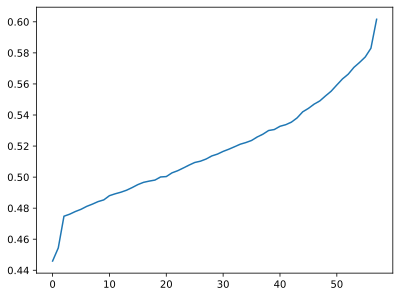

In [ ]:
# check how it does as features are dropped from the recent end
n_features = len(X_train[0])

def _compute_drop_recent():
    out = []
    for reduction in range(58):
        scores = cross_val_score(
            hist_gbr,
            X_train[:,: n_features - reduction],
            Y_train_log,
            cv=gkf,
            groups=groups_train,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        out.append(-np.mean(scores))
    return out

scores_drop_recent = cached("scores_drop_recent", _compute_drop_recent,
                            X_train, Y_train_log)

fig = plt.plot(scores_drop_recent)
plt.show()

*(Presentation note: `reduced_scores` already holds positive RMSEs, so this second plot — which negates them — is inverted. Kept for the record.)*

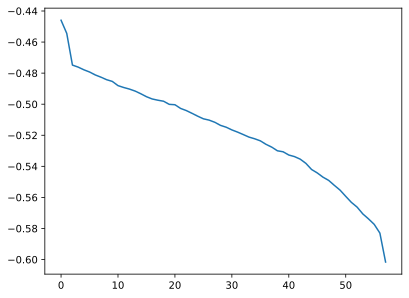

In [ ]:
neg_scores = [-score for score in scores_drop_recent]
fig = plt.plot(neg_scores)
plt.show()

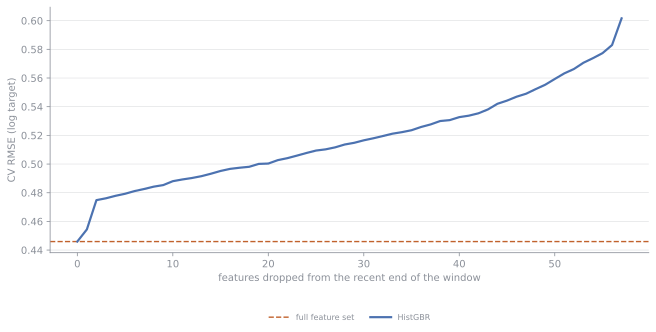

saved to /Users/sujai/Documents/player_forecasting/report/figs/feature_ablation.svg
RMSE with all features: 0.4460   with 57 dropped: 0.6016   dummy: 1.0523


In [ ]:
# --- Feature-ablation figure for the report ---------------------------------
# `scores_drop_recent` already holds positive CV RMSEs, so the `neg_scores` plot
# above is vertically flipped (negative RMSE on the y-axis). For the report we
# plot the RMSE itself, with the full-feature level marked for reference.
# Must run after the neg_scores cell, and before the range(9) zoom cell rebinds
# scores_drop_recent to a shorter list.
rmse_drop = np.array(scores_drop_recent)     # back to positive RMSE
n_dropped = np.arange(len(rmse_drop))

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.axhline(rmse_drop[0], color=LOG_COLOR, ls="--", lw=1.4,
           label="full feature set")
ax.plot(n_dropped, rmse_drop, color=RAW_COLOR, lw=2.2, label="HistGBR")
ax.set_xlabel("features dropped from the recent end of the window", color=NEUTRAL)
ax.set_ylabel("CV RMSE (log target)", color=NEUTRAL)
ax.tick_params(colors=NEUTRAL)
ax.grid(axis="y", alpha=0.3, linewidth=0.6, color=NEUTRAL)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(NEUTRAL)
leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2,
                frameon=False, fontsize=8, handlelength=2.6)
for txt in leg.get_texts():
    txt.set_color(NEUTRAL)
plt.show()

fig_dir = Path("../report/figs")
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "feature_ablation.svg", transparent=True, bbox_inches="tight")
print("saved to", (fig_dir / "feature_ablation.svg").resolve())
print(f"RMSE with all features: {rmse_drop[0]:.4f}   "
      f"with {len(rmse_drop) - 1} dropped: {rmse_drop[-1]:.4f}   "
      f"dummy: {model_scores['dummy']:.4f}")

And the complementary experiment — grow the feature set from the recent end:

[cache hit ] scores_grow_recent  <- scores_grow_recent_e33f7a34b44c.npy


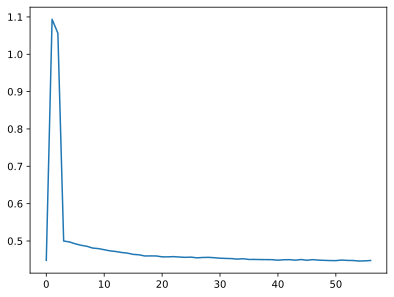

In [ ]:
# start increasing number features from end

def _compute_grow_recent():
    out = []
    for reduction in range(57):
        scores = cross_val_score(
            hist_gbr,
            X_train[:,-reduction:],
            Y_train_log,
            cv=gkf,
            groups=groups_train,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        out.append(-np.mean(scores))
    return out

scores_grow_recent = cached("scores_grow_recent", _compute_grow_recent,
                            X_train, Y_train_log)

fig = plt.plot(scores_grow_recent)
plt.show()

**Finding.** Even two stale window columns achieve ~0.58 vs the dummy's 1.05: most of the model's skill is *level-tracking* (knowing where the game sits relative to its peak). The window's shape and recency contribute the final ~25% (0.58 → 0.447).

## 8. Decay-rate features

Can summaries of *pre-window* history help? We assume post-peak playercounts decay roughly exponentially, $\exp(-\lambda t)$, and add $\lambda$ as a feature.

### 8.1 Two-point estimate

First a crude estimate: time since the last causal peak, and $\lambda$ from the window-end value alone. The extractor also records `time_since_peak`:

In [ ]:
def extractor_decay(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    peak_threshold (float): fraction of 1 - the threshold for designating a past normalised playercount as a 'peak'

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    window_start = 0 
    n_days = len(time_series)
    
    while window_start + past_window + embargo + future_window - 1 < n_days:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[window_start + past_window + embargo: window_start + past_window + embargo + future_window]):
            window_start += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[window_start: window_start + past_window]):
            window_start += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            peak_at_window_end = causal_peaks[window_start + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[window_start + past_window + embargo: window_start + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / peak_at_window_end

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(peak_at_window_end)

            # include the cna counts since the last peak before the window.
            index_of_window_end = window_start + past_window - 1
            peak_pointer = index_of_window_end
            found_peak = False

            while peak_pointer > 0 and found_peak == False:
                if time_series[peak_pointer] >= peak_threshold:
                    found_peak = True
                
                else:
                    peak_pointer -= 1
            
            time_since_peak = index_of_window_end - peak_pointer
            decay_rate = - np.log(time_series[index_of_window_end] + 0.01) / (time_since_peak + 1)

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[window_start: window_start + past_window],
                           avg,
                           game_id,
                           window_start + past_window - 1,
                           log_causal_peak,
                           time_since_peak,
                           decay_rate))
            # shift along
            window_start += future_window

    return points

In [ ]:
def extractor_decay_logfit(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold):
    """
    Identical to extractor_decay above, except for how the decay rate is found.

    extractor_decay uses a crude two-point estimate that assumes the series fell
    from exactly 1.0 at the peak straight to its current value:

        decay_rate = -log(cna_end + 0.01) / (time_since_peak + 1)

    so a single noisy end-of-window value fixes the whole rate. Here the rate is
    instead the least-squares slope of log(cna + 0.01) over every day from the
    peak to the window end, which uses the shape of the entire decline.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    peak_threshold (float): fraction of 1 - the threshold for designating a past normalised playercount as a 'peak'

    Returns: list of tuples (window, future average, game_id, window end index,
             log causal peak, time since peak, decay rate)
    """
    points = []
    window_start = 0
    n_days = len(time_series)

    while window_start + past_window + embargo + future_window - 1 < n_days:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[window_start + past_window + embargo: window_start + past_window + embargo + future_window]):
            window_start += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[window_start: window_start + past_window]):
            window_start += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            peak_at_window_end = causal_peaks[window_start + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[window_start + past_window + embargo: window_start + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / peak_at_window_end

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(peak_at_window_end)

            # walk back to the last day the series was at peak level
            index_of_window_end = window_start + past_window - 1
            peak_pointer = index_of_window_end
            found_peak = False

            while peak_pointer > 0 and found_peak == False:
                if time_series[peak_pointer] >= peak_threshold:
                    found_peak = True

                else:
                    peak_pointer -= 1

            time_since_peak = index_of_window_end - peak_pointer

            # least-squares slope of log(cna) over the whole post-peak segment.
            # The search above can walk back past window_start, and only the
            # window itself was NaN-checked, so drop any NaN days before fitting.
            series_since_peak = np.array(time_series[peak_pointer: index_of_window_end + 1], dtype=float)
            days_since_peak = np.arange(len(series_since_peak))

            valid = ~np.isnan(series_since_peak)

            if valid.sum() > 1:
                decay_rate = - np.polyfit(days_since_peak[valid],
                                          np.log(series_since_peak[valid] + 0.01), 1)[0]
            else:
                decay_rate = 0.0

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[window_start: window_start + past_window],
                           avg,
                           game_id,
                           window_start + past_window - 1,
                           log_causal_peak,
                           time_since_peak,
                           decay_rate))
            # shift along
            window_start += future_window

    return points

In [ ]:
data = []

# generate data points
for column in frames_shuffled["cna"]:
    game_id = column
    time_series = frames_shuffled["cna"][column].tolist()
    causal_peaks = frames_shuffled["cpa"][column].tolist()
    roll_average = frames_shuffled["pca"][column].tolist()
    data.append(extractor_decay(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0))

In [ ]:
data_train = data[:n_train_games]
data_test = data[n_train_games:]

# flatten
train_points = [point for game in data_train for point in game]
test_points = [point for game in data_test for point in game]

print("There are " + str(len(test_points)) + " test data points.")
print("There are " + str(len(train_points)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


Rebuild the arrays (now with `deepcopy` so re-running the cell cannot mutate the underlying points):

In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in train_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[6])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in test_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[6])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_gbr = HistGradientBoostingRegressor(random_state=42)

scores = cross_val_score(
    hist_gbr,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) and decay rate has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr_decay"] = -np.mean(scores)

The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) and decay rate has a RMSE of: 0.4469214580319347


**Same features, fitted decay rate.** `extractor_decay` sets the decay from a
single two-point estimate; `extractor_decay_logfit` replaces it with a
least-squares slope of $\log(\text{cna})$ over the whole post-peak segment and
keeps everything else — including `time_since_peak` — identical. Section 8.2
below changes the decay *and* drops `time_since_peak`, so this cell isolates the
effect of the decay estimate alone.

In [ ]:
data = []

# generate data points
for column in frames_shuffled["cna"]:
    game_id = column
    time_series = frames_shuffled["cna"][column].tolist()
    causal_peaks = frames_shuffled["cpa"][column].tolist()
    roll_average = frames_shuffled["pca"][column].tolist()
    data.append(extractor_decay_logfit(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0))

In [ ]:
data_train = data[:n_train_games]
data_test = data[n_train_games:]

# flatten
train_points = [point for game in data_train for point in game]
test_points = [point for game in data_test for point in game]

print("There are " + str(len(test_points)) + " test data points.")
print("There are " + str(len(train_points)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in train_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[6])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in test_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[6])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

print("X_train:", X_train.shape, " (cols 56=time since start, 57=log peak, 58=fitted decay)")

X_train: (66424, 59)  (cols 56=time since start, 57=log peak, 58=fitted decay)


In [ ]:
hist_gbr = HistGradientBoostingRegressor(random_state=42)

scores = cross_val_score(
    hist_gbr,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

model_scores["histgbr_decay_logfit"] = -np.mean(scores)

print(f"HistGBR, fitted (log-linear) decay rate : {-np.mean(scores):.4f}  (fold std {np.std(scores):.4f})")
print(f"  same features, two-point decay (8.1) : {model_scores['histgbr_decay']:.4f}")
print(f"  window + time + log peak only (7)    : {model_scores['histgbr']:.4f}")
print(f"  dummy                                : {model_scores['dummy']:.4f}")

HistGBR, fitted (log-linear) decay rate : 0.4455  (fold std 0.0124)
  same features, two-point decay (8.1) : 0.4469
  window + time + log peak only (7)    : 0.4470
  dummy                                : 1.0523


### 8.2 Two-parameter decay fit

Both decay estimates so far assume a pure exponential, which forces the fitted
curve toward zero. Real playerbases flatten out instead, which is why the
post-peak exponential baseline in section 6 did so badly. Here we fit the
post-peak segment to

$$\text{cna}(t) = N\left(e^{-\lambda t} - 1\right) + 1$$

which is pinned at $\text{cna}(0) = 1$ (the causal peak, exactly where the
segment starts) and decays at rate $\lambda$ toward an asymptote of $1 - N$.
So $N$ is the *depth* of the eventual decline and $\lambda$ its *speed*, and we
hand the model both rather than a single conflated rate.

Fitting is nonlinear (`scipy.optimize.curve_fit`), so unlike the polyfit version
it can fail to converge; those windows fall back to $(N, \lambda) = (0, 0)$.

In [ ]:
from scipy.optimize import curve_fit

def two_param_decay(t, N, lam):
    """CNA falling from 1 at the causal peak toward an asymptote of 1 - N, at rate lam."""
    return N * (np.exp(-lam * t) - 1.0) + 1.0

def fit_two_param_decay(series_since_peak):
    """
    Least-squares fit of two_param_decay to one post-peak segment.

    Returns (N, lam), or (0.0, 0.0) if the segment is too short or the fit fails
    to converge. The segment is indexed from the peak, so t = 0, 1, 2, ...
    """
    series = np.asarray(series_since_peak, dtype=float)
    t = np.arange(len(series), dtype=float)

    valid = ~np.isnan(series)
    if valid.sum() < 3:                      # two free parameters need >= 3 points
        return 0.0, 0.0

    # start from the drop actually observed by the end of the segment
    n0 = float(np.clip(1.0 - series[valid][-1], 1e-3, 1.5))
    try:
        popt, _ = curve_fit(two_param_decay, t[valid], series[valid],
                            p0=(n0, 0.02),
                            bounds=([0.0, 0.0], [2.0, 1.0]),
                            maxfev=2000)
        return float(popt[0]), float(popt[1])
    except (RuntimeError, ValueError):
        return 0.0, 0.0


def extractor_decay_twoparam(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold):
    """
    As extractor_decay_logfit, but the post-peak segment is fitted to
    N(exp(-lam t) - 1) + 1 and BOTH parameters are returned as features.

    Returns: list of tuples (window, future average, game_id, window end index,
             log causal peak, time since peak, N, lam)
    """
    points = []
    window_start = 0
    n_days = len(time_series)

    while window_start + past_window + embargo + future_window - 1 < n_days:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[window_start + past_window + embargo: window_start + past_window + embargo + future_window]):
            window_start += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[window_start: window_start + past_window]):
            window_start += past_window

        # else, create a datapoint
        else:
            peak_at_window_end = causal_peaks[window_start + past_window - 1]

            avg = sum(roll_average[window_start + past_window + embargo: window_start + past_window + embargo + future_window]) / float(future_window)
            avg = avg / peak_at_window_end

            log_causal_peak = np.log(peak_at_window_end)

            # walk back to the last day the series was at peak level
            index_of_window_end = window_start + past_window - 1
            peak_pointer = index_of_window_end
            found_peak = False

            while peak_pointer > 0 and found_peak == False:
                if time_series[peak_pointer] >= peak_threshold:
                    found_peak = True

                else:
                    peak_pointer -= 1

            time_since_peak = index_of_window_end - peak_pointer

            series_since_peak = time_series[peak_pointer: index_of_window_end + 1]
            decay_depth, decay_rate = fit_two_param_decay(series_since_peak)

            points.append((time_series[window_start: window_start + past_window],
                           avg,
                           game_id,
                           window_start + past_window - 1,
                           log_causal_peak,
                           time_since_peak,
                           decay_depth,
                           decay_rate))
            # shift along
            window_start += future_window

    return points

In [ ]:
data = []

# generate data points (nonlinear fit per window - slower than the polyfit versions)
for column in frames_shuffled["cna"]:
    game_id = column
    time_series = frames_shuffled["cna"][column].tolist()
    causal_peaks = frames_shuffled["cpa"][column].tolist()
    roll_average = frames_shuffled["pca"][column].tolist()
    data.append(extractor_decay_twoparam(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0))

In [ ]:
data_train = data[:n_train_games]
data_test = data[n_train_games:]

# flatten
train_points = [point for game in data_train for point in game]
test_points = [point for game in data_test for point in game]

print("There are " + str(len(test_points)) + " test data points.")
print("There are " + str(len(train_points)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in train_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[6])
    series.append(point[7])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in test_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[6])
    series.append(point[7])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

print("X_train:", X_train.shape,
      " (56=time, 57=log peak, 58=N depth, 59=lambda rate)")

# how often did the nonlinear fit fall back?
fallback = np.mean((X_train[:, 58] == 0.0) & (X_train[:, 59] == 0.0))
print(f"windows falling back to (0, 0): {100 * fallback:.1f}%")
print(f"N     - median {np.median(X_train[:, 58]):.3f}, "
      f"5-95% [{np.percentile(X_train[:, 58], 5):.3f}, {np.percentile(X_train[:, 58], 95):.3f}]")
print(f"lambda- median {np.median(X_train[:, 59]):.4f}, "
      f"5-95% [{np.percentile(X_train[:, 59], 5):.4f}, {np.percentile(X_train[:, 59], 95):.4f}]")

X_train: (66424, 60)  (56=time, 57=log peak, 58=N depth, 59=lambda rate)
windows falling back to (0, 0): 1.7%
N     - median 0.622, 5-95% [0.165, 1.269]
lambda- median 0.0555, 5-95% [0.0030, 0.1964]


In [ ]:
hist_gbr = HistGradientBoostingRegressor(random_state=42)

scores = cross_val_score(
    hist_gbr,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

model_scores["histgbr_decay_twoparam"] = -np.mean(scores)

print(f"HistGBR, two-parameter decay (N, lambda) : {-np.mean(scores):.4f}  (fold std {np.std(scores):.4f})")
print(f"  fitted log-linear decay (8.1)          : {model_scores['histgbr_decay_logfit']:.4f}")
print(f"  two-point decay (8.1)                  : {model_scores['histgbr_decay']:.4f}")
print(f"  window + time + log peak only (7)      : {model_scores['histgbr']:.4f}")
print(f"  dummy                                  : {model_scores['dummy']:.4f}")

HistGBR, two-parameter decay (N, lambda) : 0.4429  (fold std 0.0125)
  fitted log-linear decay (8.1)          : 0.4455
  two-point decay (8.1)                  : 0.4469
  window + time + log peak only (7)      : 0.4470
  dummy                                  : 1.0523


### 8.3 Log-linear fit (polyfit)

The two-point estimate is noisy — a least-squares slope of $\log(\text{cna})$ over the whole post-peak segment uses all the information between peak and window:

In [ ]:
def extractor_decay_polyfit(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    peak_threshold (float): fraction of 1 - the threshold for designating a past normalised playercount as a 'peak'

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    window_start = 0 
    n_days = len(time_series)
    
    while window_start + past_window + embargo + future_window - 1 < n_days:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[window_start + past_window + embargo: window_start + past_window + embargo + future_window]):
            window_start += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[window_start: window_start + past_window]):
            window_start += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            peak_at_window_end = causal_peaks[window_start + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[window_start + past_window + embargo: window_start + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / peak_at_window_end

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(peak_at_window_end)

            # include the cna counts since the last peak before the window.
            index_of_window_end = window_start + past_window - 1
            peak_pointer = index_of_window_end
            found_peak = False

            while peak_pointer > 0 and found_peak == False:
                if time_series[peak_pointer] >= peak_threshold:
                    found_peak = True
                
                else:
                    peak_pointer -= 1
            
            series_since_peak = np.array(time_series[peak_pointer: index_of_window_end + 1])
            time_since_peak = np.arange(len(series_since_peak))

            # the tilde flips T and F:
            mask = ~np.isnan(time_since_peak)

            if mask.sum() > 1:
                decay_rate = - np.polyfit(time_since_peak, np.log(series_since_peak + 0.01), 1)[0]
            else:
                decay_rate = 0.0

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[window_start: window_start + past_window],
                           avg,
                           game_id,
                           window_start + past_window - 1,
                           log_causal_peak,
                           decay_rate
                           ))
            # shift along
            window_start += future_window

    return points

In [ ]:
data = []

# generate data points
for column in frames_shuffled["cna"]:
    game_id = column
    time_series = frames_shuffled["cna"][column].tolist()
    causal_peaks = frames_shuffled["cpa"][column].tolist()
    roll_average = frames_shuffled["pca"][column].tolist()
    data.append(extractor_decay_polyfit(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0))

In [ ]:
data_train = data[:n_train_games]
data_test = data[n_train_games:]

# flatten
train_points = [point for game in data_train for point in game]
test_points = [point for game in data_test for point in game]

print("There are " + str(len(test_points)) + " test data points.")
print("There are " + str(len(train_points)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


In [ ]:
len(train_points[0])

6

In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in train_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in test_points:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_gbr = HistGradientBoostingRegressor(random_state=42)

scores = cross_val_score(
    hist_gbr,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using polyfit decay rate has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr_decay_polyfit"] = -np.mean(scores)

The histgb regressor using polyfit decay rate has a RMSE of: 0.44539706016087466


### 8.4 Summary features + linear regression

A different tack: instead of feeding the model all 56 window days, compress the
window into four order statistics — mean, standard deviation, max and min — and
fit ordinary least squares on those. This asks how much of the signal survives
throwing away the *shape* of the trajectory and keeping only its location and
spread.

Features are deliberately left unscaled here; scaling comes in the next step.
(OLS is scale-invariant in its fitted predictions, so this costs nothing yet —
it matters once regularisation enters.)

X_train (66424, 59) -> (66424, 4)


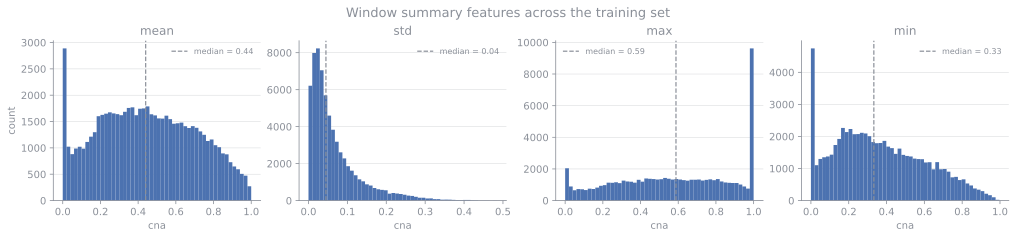

In [ ]:
# --- compress each 56-day window into four summary statistics ---------------
WINDOW = 56

def summarise_window(X):
    """56-day window -> (mean, std, max, min). Ignores the auxiliary columns."""
    w = X[:, :WINDOW]
    return np.column_stack([w.mean(axis=1), w.std(axis=1),
                            w.max(axis=1), w.min(axis=1)])

SUMMARY_NAMES = ["mean", "std", "max", "min"]

X_train_summary = summarise_window(X_train)
X_test_summary = summarise_window(X_test)
print("X_train", X_train.shape, "->", X_train_summary.shape)

# distribution of each feature across the training set
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)

for ax, name, col in zip(axes, SUMMARY_NAMES, X_train_summary.T):
    ax.hist(col, bins=50, color=RAW_COLOR, edgecolor="none")
    ax.axvline(np.median(col), color=NEUTRAL, linestyle="--", linewidth=1.2,
               label=f"median = {np.median(col):.2f}")
    ax.set_title(name, fontsize=12, color=NEUTRAL)
    ax.set_xlabel("cna", color=NEUTRAL)
    ax.tick_params(colors=NEUTRAL)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6, color=NEUTRAL)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(NEUTRAL)
    leg = ax.legend(frameon=False, fontsize=8)
    for t in leg.get_texts():
        t.set_color(NEUTRAL)

axes[0].set_ylabel("count", color=NEUTRAL)
fig.suptitle("Window summary features across the training set",
             fontsize=13, color=NEUTRAL)
plt.show()

In [ ]:
# --- OLS on the four summary features --------------------------------------
from sklearn.linear_model import LinearRegression

scores = cross_val_score(
    LinearRegression(),
    X_train_summary,
    Y_train_log,
    cv=GroupKFold(n_splits=5),
    groups=groups_train,
    scoring="neg_root_mean_squared_error",
)

score_summary = -np.mean(scores)
model_scores["linreg_summary"] = score_summary

print(f"Summary-feature OLS RMSE: {score_summary:.4f}  (fold std {np.std(scores):.4f})")
print(f"  dummy, for scale:       {model_scores.get('dummy', float('nan')):.4f}")
print(f"  HistGBR, full window:   0.4455")

# which way does each feature push the prediction?
fitted = LinearRegression().fit(X_train_summary, Y_train_log)
for name, coef in zip(SUMMARY_NAMES, fitted.coef_):
    print(f"  coef[{name:<4}] = {coef:+.3f}")

Summary-feature OLS RMSE: 0.6791  (fold std 0.0237)
  dummy, for scale:       1.0523
  HistGBR, full window:   0.4455
  coef[mean] = -0.156
  coef[std ] = -5.617
  coef[max ] = +2.563
  coef[min ] = +0.923


### 8.5 Log-transforming the `std` feature

The `std` histogram above is heavily right-skewed — most windows are quiet, a
long tail is volatile. OLS fits a coefficient to the feature *as given*, so a
skewed predictor lets the few high-variance windows dominate the least-squares
solution. Replacing `std` with $\log(\text{std} + 0.01)$ spreads that tail out,
the same reasoning (and the same offset) as the log target in section 5.3.

Everything else is held fixed: same three other features, same folds, still
unscaled.

windows with std < 0.01: 6422 of 66424 (9.7%)


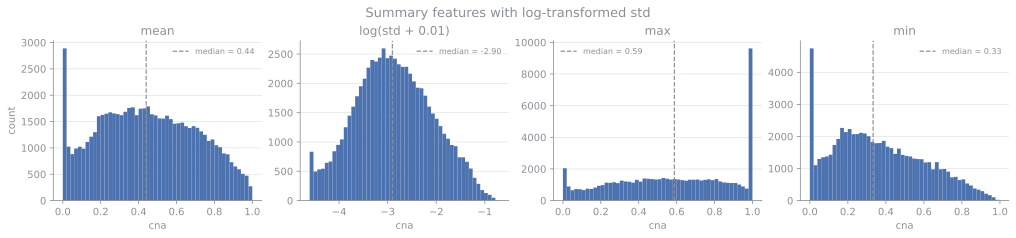


log-std OLS RMSE:  0.6494  (fold std 0.0220)
  raw-std OLS was: 0.6791
  change:          +0.0296
  coef[mean            ] = -1.598
  coef[log(std + 0.01) ] = +0.725
  coef[max             ] = -1.524
  coef[min             ] = +6.126


In [ ]:
# --- same four features, but log-transform std ------------------------------
STD_COL = SUMMARY_NAMES.index("std")

def log_std(X_summary):
    """Replace the std column with log(std + 0.01)."""
    out = X_summary.copy()
    out[:, STD_COL] = np.log(out[:, STD_COL] + 0.01)
    return out

X_train_logstd = log_std(X_train_summary)
X_test_logstd = log_std(X_test_summary)

LOGSTD_NAMES = ["mean", "log(std + 0.01)", "max", "min"]

# how many windows sit at (near) zero variance, i.e. in the offset-dominated
# part of the transform? these are flat/dead windows.
n_flat = int((X_train_summary[:, STD_COL] < 0.01).sum())
print(f"windows with std < 0.01: {n_flat} of {len(X_train_summary)} "
      f"({100 * n_flat / len(X_train_summary):.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)

for ax, name, col in zip(axes, LOGSTD_NAMES, X_train_logstd.T):
    ax.hist(col, bins=50, color=RAW_COLOR, edgecolor="none")
    ax.axvline(np.median(col), color=NEUTRAL, linestyle="--", linewidth=1.2,
               label=f"median = {np.median(col):.2f}")
    ax.set_title(name, fontsize=12, color=NEUTRAL)
    ax.set_xlabel("cna", color=NEUTRAL)
    ax.tick_params(colors=NEUTRAL)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6, color=NEUTRAL)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(NEUTRAL)
    leg = ax.legend(frameon=False, fontsize=8)
    for t in leg.get_texts():
        t.set_color(NEUTRAL)

axes[0].set_ylabel("count", color=NEUTRAL)
fig.suptitle("Summary features with log-transformed std",
             fontsize=13, color=NEUTRAL)
plt.show()

scores = cross_val_score(
    LinearRegression(),
    X_train_logstd,
    Y_train_log,
    cv=GroupKFold(n_splits=5),
    groups=groups_train,
    scoring="neg_root_mean_squared_error",
)

score_logstd = -np.mean(scores)
model_scores["linreg_summary_logstd"] = score_logstd

print(f"\nlog-std OLS RMSE:  {score_logstd:.4f}  (fold std {np.std(scores):.4f})")
print(f"  raw-std OLS was: {model_scores['linreg_summary']:.4f}")
print(f"  change:          {model_scores['linreg_summary'] - score_logstd:+.4f}")

fitted = LinearRegression().fit(X_train_logstd, Y_train_log)
for name, coef in zip(LOGSTD_NAMES, fitted.coef_):
    print(f"  coef[{name:<16}] = {coef:+.3f}")

### 8.6 Decorrelated summary features

The four features above are all in units of cna *level* — mean, max and min are
three readings of "where is this game sitting", and `std` scales with level too
(a game at 0.8 has more absolute room to wiggle than one at 0.05). On the real
windows their mean pairwise $|r|$ is 0.59, with mean–min at 0.95, which is what
produced the large opposing coefficients in 8.5.

This set asks one independent question per feature:

| Feature | Question |
|---|---|
| `log_level_end` | Where is it *now*? |
| `log_slope` | Which way is it going? |
| `log_resid_sd` | How noisy *around* that trend? |
| `drawdown` | How far below its window peak? |
| `recent_delta` | Is the decline accelerating? |

Three of the five are differences of logs — i.e. ratios — so the overall level
cancels rather than being restated. Note that decorrelation buys *stable,
interpretable coefficients*; whether it also buys accuracy is what the CV below
answers.

current four   mean |r| 0.59   max |r| 0.95   condition number 444
decorrelated   mean |r| 0.32   max |r| 0.55   condition number 17


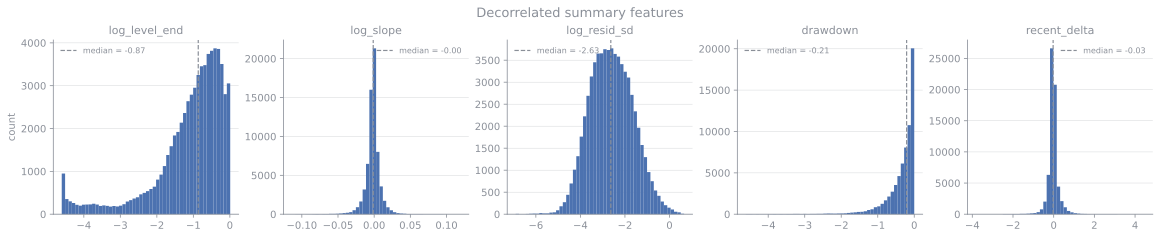


decorrelated OLS RMSE: 0.4932  (fold std 0.0185)
  raw-std OLS (8.5):   0.6791
  log-std OLS (8.6):   0.6494
  dummy:               1.0523
  coef[log_level_end ] = +0.907
  coef[log_slope     ] = -9.832
  coef[log_resid_sd  ] = -0.076
  coef[drawdown      ] = +0.179
  coef[recent_delta  ] = -0.545


In [ ]:
# --- decorrelated summary features -----------------------------------------
DAYS = np.arange(WINDOW)

def decorrelated_features(X):
    """56-day window -> five features asking independent questions."""
    lw = np.log(X[:, :WINDOW] + 0.01)          # work in log space throughout

    # least-squares trend through the log window
    slope, intercept = np.polyfit(DAYS, lw.T, deg=1)
    resid = lw - (slope[:, None] * DAYS + intercept[:, None])

    return np.column_stack([
        lw[:, -1],                              # log level at window end
        slope,                                  # log-space trend
        np.log(resid.std(axis=1) + 1e-3),       # volatility AROUND the trend
        lw[:, -1] - lw.max(axis=1),             # drawdown from window peak
        lw[:, -7:].mean(axis=1) - lw[:, -28:-7].mean(axis=1),   # recent change
    ])

DECORR_NAMES = ["log_level_end", "log_slope", "log_resid_sd",
                "drawdown", "recent_delta"]

X_train_decorr = decorrelated_features(X_train)
X_test_decorr = decorrelated_features(X_test)

# how much less redundant is this set? condition number of the correlation
# matrix is the quantity that governs how unstable the OLS coefficients are.
for name, Xa, names in [("current four", X_train_summary, SUMMARY_NAMES),
                        ("decorrelated", X_train_decorr, DECORR_NAMES)]:
    C = np.corrcoef(Xa.T)
    off = C[~np.eye(len(names), dtype=bool)]
    ev = np.linalg.eigvalsh(C)
    print(f"{name:<14} mean |r| {np.abs(off).mean():.2f}   "
          f"max |r| {np.abs(off).max():.2f}   "
          f"condition number {ev.max() / max(ev.min(), 1e-12):.0f}")

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), constrained_layout=True)

for ax, name, col in zip(axes, DECORR_NAMES, X_train_decorr.T):
    ax.hist(col, bins=50, color=RAW_COLOR, edgecolor="none")
    ax.axvline(np.median(col), color=NEUTRAL, linestyle="--", linewidth=1.2,
               label=f"median = {np.median(col):.2f}")
    ax.set_title(name, fontsize=11, color=NEUTRAL)
    ax.tick_params(colors=NEUTRAL)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6, color=NEUTRAL)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(NEUTRAL)
    leg = ax.legend(frameon=False, fontsize=8)
    for t in leg.get_texts():
        t.set_color(NEUTRAL)

axes[0].set_ylabel("count", color=NEUTRAL)
fig.suptitle("Decorrelated summary features", fontsize=13, color=NEUTRAL)
plt.show()

scores = cross_val_score(
    LinearRegression(),
    X_train_decorr,
    Y_train_log,
    cv=GroupKFold(n_splits=5),
    groups=groups_train,
    scoring="neg_root_mean_squared_error",
)

score_decorr = -np.mean(scores)
model_scores["linreg_decorrelated"] = score_decorr

print(f"\ndecorrelated OLS RMSE: {score_decorr:.4f}  (fold std {np.std(scores):.4f})")
print(f"  raw-std OLS (8.5):   {model_scores['linreg_summary']:.4f}")
print(f"  log-std OLS (8.6):   {model_scores['linreg_summary_logstd']:.4f}")
print(f"  dummy:               {model_scores.get('dummy', float('nan')):.4f}")

fitted = LinearRegression().fit(X_train_decorr, Y_train_log)
for name, coef in zip(DECORR_NAMES, fitted.coef_):
    print(f"  coef[{name:<14}] = {coef:+.3f}")

## 9. Error analysis

Where does the remaining error live? Out-of-fold predictions for every training window (each predicted by a model that never saw its game):

In [ ]:
from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(HistGradientBoostingRegressor(random_state=42),
                  X_train,
                  Y_train_log,
                  groups = groups_train,
                  cv = GroupKFold(n_splits=5)
)

In [ ]:
scores = cross_val_score(
    HistGradientBoostingRegressor(random_state=42),
    X_train,
    Y_train_log,
    cv=GroupKFold(n_splits=5),
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print(-scores.mean())

0.44539706016087466


Split windows into *big errors* (absolute log-residual > 1, i.e. off by more than a factor of ~2.7) and the rest, then compare their feature distributions:

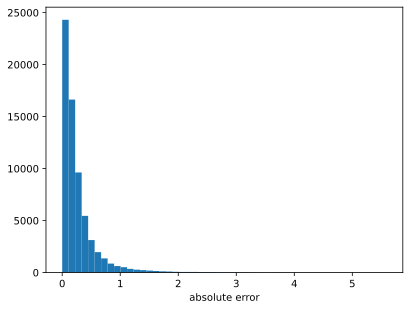

In [ ]:
residuals = np.abs(predictions - Y_train_log)
fig, ax = plt.subplots()
plt.hist(residuals, bins=50)
ax.set_xlabel(xlabel="absolute error")
plt.show()

residuals = np.abs(predictions - Y_train_log)

mask = residuals > 1.0            # boolean array
X_big_errors  = X_train[mask]     # rows where error > 1
X_small_errors = X_train[~mask]   # everything else

In [ ]:
big_error_time = X_big_errors[:,56]
big_error_log_peak = X_big_errors[:,57]
big_error_lam = X_big_errors[:,58]

small_error_time = X_small_errors[:,56]
small_error_log_peak = X_small_errors[:,57]
small_error_lam = X_small_errors[:,58]

Time of window end:

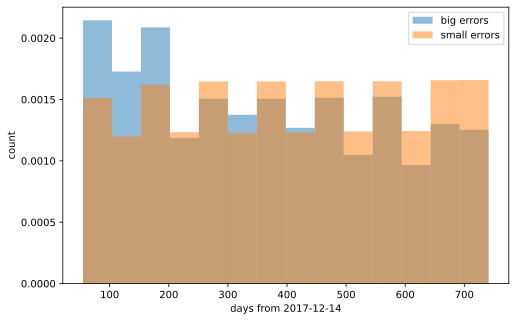

In [ ]:
a = big_error_time
b = small_error_time

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    15
)   # shared edges so the bars line up

ax.hist(a, bins=bins, alpha=0.5, label="big errors", density=True)
ax.hist(b, bins=bins, alpha=0.5, label="small errors", density=True)

ax.set_xlabel("days from 2017-12-14")
ax.set_ylabel("count")
ax.legend()
plt.show()

It would seem that a lot of the big errors come from windows near the start of the recording period. This plausibly reflects selection bias — games were chosen for being popular around the collection start, so the early sample is enriched with games at their hype peak, not in steady state — compounded by the causal normalisation having little history to work with early on.

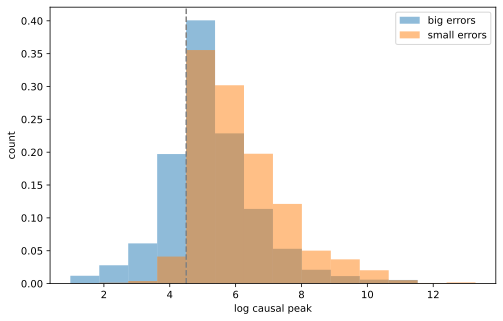

In [ ]:
a = big_error_log_peak
b = small_error_log_peak

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    15
)   # shared edges so the bars line up

ax.hist(a, bins=bins, alpha=0.5, label="big errors", density=True)
ax.hist(b, bins=bins, alpha=0.5, label="small errors", density=True)
ax.axvline(x=4.5, linestyle="--", color="grey")

ax.set_xlabel("log causal peak")
ax.set_ylabel("count")
ax.legend()
plt.show()

Smaller-error points tend to have a larger log causal peak; below ~4.5 (peaks under ~90 players) big errors dominate. Prediction error rises as the playercount shrinks — in log space, integer-level noise on small games is proportionally huge.

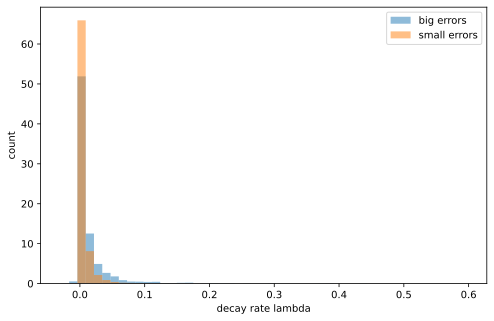

In [ ]:
a = big_error_lam[~np.isnan(big_error_lam)]
b = small_error_lam[~np.isnan(small_error_lam)]

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    50
)   # shared edges so the bars line up

ax.hist(a, bins=bins, alpha=0.5, label="big errors", density=True)
ax.hist(b, bins=bins, alpha=0.5, label="small errors", density=True)

ax.set_xlabel("decay rate lambda")
ax.set_ylabel("count")
ax.legend()
plt.show()

Higher fitted decay rates also associate with higher errors — mid-collapse games are intrinsically hard to extrapolate nine weeks out.

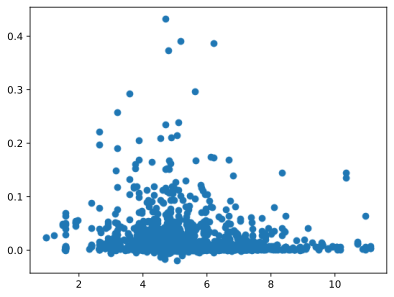

In [ ]:
plt.scatter(big_error_log_peak, big_error_lam, rasterized=True)
plt.show()

## 10. Tag features (in progress)

Static metadata — genre/feature tags per game — is the first information source from *outside* the playercount series. Frequency survey and alignment with the games kept by the dud filter:

In [ ]:
tag_path = Path("../data/mendeley/applicationTags.csv")
tags = pd.read_csv(tag_path, header=None)

# extract the tags only
tags_only = tags.iloc[:,1:]
# make all tags lowercase
tags_only = tags_only.map(lambda x: x.lower() if isinstance(x, str) else x)
tags_only = tags_only.stack()

counts = tags_only.value_counts()

counts.iloc[:5]


singleplayer    1335
action          1268
adventure       1091
multiplayer     1041
indie            954
Name: count, dtype: int64

In [ ]:
tags = tags.T
header_row = tags.iloc[0]
tags = tags[1:]
tags.columns = header_row
tags.head()

,578080,570,730,622590,359550,271590,238960,230410,440,252950,...,568570,562760,394690,64000,227860,34000,202480,429050,209650,304730
1,Survival,Free to Play,FPS,NaN,FPS,Open World,Free to Play,Free to Play,Free to Play,Multiplayer,...,Crafting,Indie,Early Access,Strategy,Strategy,NaN,NaN,Early Access,Dog,Simulation
2,Shooter,MOBA,Multiplayer,NaN,Multiplayer,Action,Action RPG,Action,Multiplayer,Racing,...,Survival,Casual,Mini Golf,World War II,Building,NaN,NaN,Simulation,FPS,Trains
3,Multiplayer,Strategy,Shooter,NaN,Tactical,Multiplayer,RPG,Co-op,FPS,Soccer,...,Open World,Simulation,Massively Multiplayer,Tactical,Sandbox,NaN,NaN,Underwater,Action,Management
4,PvP,Multiplayer,Action,NaN,Action,Third Person,Hack and Slash,Multiplayer,Action,Sports,...,Sandbox,NaN,Casual,War,Indie,NaN,NaN,Multiplayer,Multiplayer,Strategy
5,FPS,Team-Based,Team-Based,NaN,Shooter,First-Person,Multiplayer,Third-Person Shooter,Shooter,Competitive,...,Simulation,NaN,Character Customization,RTS,Survival,NaN,NaN,Action,Shooter,Economy


In [ ]:
all_cols = header_row.tolist()
kept_cols = [int(i) for i in frames_shuffled["cna"].columns.tolist()]
dropped_cols = [col for col in all_cols if col not in kept_cols]

In [ ]:
tags = tags.drop(columns=dropped_cols)
tags.head()

,578080,570,730,622590,359550,271590,238960,230410,440,252950,...,568570,562760,394690,64000,227860,34000,202480,429050,209650,304730
1,Survival,Free to Play,FPS,NaN,FPS,Open World,Free to Play,Free to Play,Free to Play,Multiplayer,...,Crafting,Indie,Early Access,Strategy,Strategy,NaN,NaN,Early Access,Dog,Simulation
2,Shooter,MOBA,Multiplayer,NaN,Multiplayer,Action,Action RPG,Action,Multiplayer,Racing,...,Survival,Casual,Mini Golf,World War II,Building,NaN,NaN,Simulation,FPS,Trains
3,Multiplayer,Strategy,Shooter,NaN,Tactical,Multiplayer,RPG,Co-op,FPS,Soccer,...,Open World,Simulation,Massively Multiplayer,Tactical,Sandbox,NaN,NaN,Underwater,Action,Management
4,PvP,Multiplayer,Action,NaN,Action,Third Person,Hack and Slash,Multiplayer,Action,Sports,...,Sandbox,NaN,Casual,War,Indie,NaN,NaN,Multiplayer,Multiplayer,Strategy
5,FPS,Team-Based,Team-Based,NaN,Shooter,First-Person,Multiplayer,Third-Person Shooter,Shooter,Competitive,...,Simulation,NaN,Character Customization,RTS,Survival,NaN,NaN,Action,Shooter,Economy


## 11. Summary of results

All scores are 5-fold `GroupKFold` RMSE on the log target, grouped by game. Every
estimator uses `random_state=42`. The table below is generated from
`model_scores`, so it cannot disagree with the run that produced it.

The decay rows add only their decay estimate to the section 7 feature set.
`time_since_peak` is no longer included, so they isolate the decay rate.